## Color-color box selection

### **LBG Selection via $u$-dropout Technique**

**Objective:** To isolate Lyman Break Galaxies (LBGs) at $z \sim 2$ by identifying the Lyman limit break ($912\text{ \AA}$) as it passes through the $u$-band filter.

**Selection Criteria:** 
We adopt a modified version of the classic $u$-dropout color-box:
*   **Color-Color Box:** $(u-g) > 0.3$, $-0.5 < (g-r) < 1.0$.
*   **Diagonal Cut:** $(u-g) > 2.2(g-r) + 0.32$ OR $[(u-g) > 1.6(g-r) + 0.75 \text{ AND } (u-g) > 0.9]$.
*   **Quality Cuts:** $22.5 < r < 23.75$ and clean photometry flags.

**Results:**
*   **Left Panel:** The color-color distribution demonstrates that high-redshift sources ($z_{\rm phot} \gtrsim 2.5$, yellow/orange) are effectively isolated within the defined blue boundary, well-separated from the low-redshift foreground (purple).
*   **Right Panel:** The redshift histogram of the selected sample shows a robust peak at $z \approx 2.8$. The selection yields **2,028 candidates** with a high-redshift purity of **78.9%** ($z > 2$). Minor contamination at $z < 0.5$ is noted, likely due to the "red-galaxy" color degeneracy.

Total sources: 5,263,013
After base cuts: 132,955
Selected by color-color box: 2,028


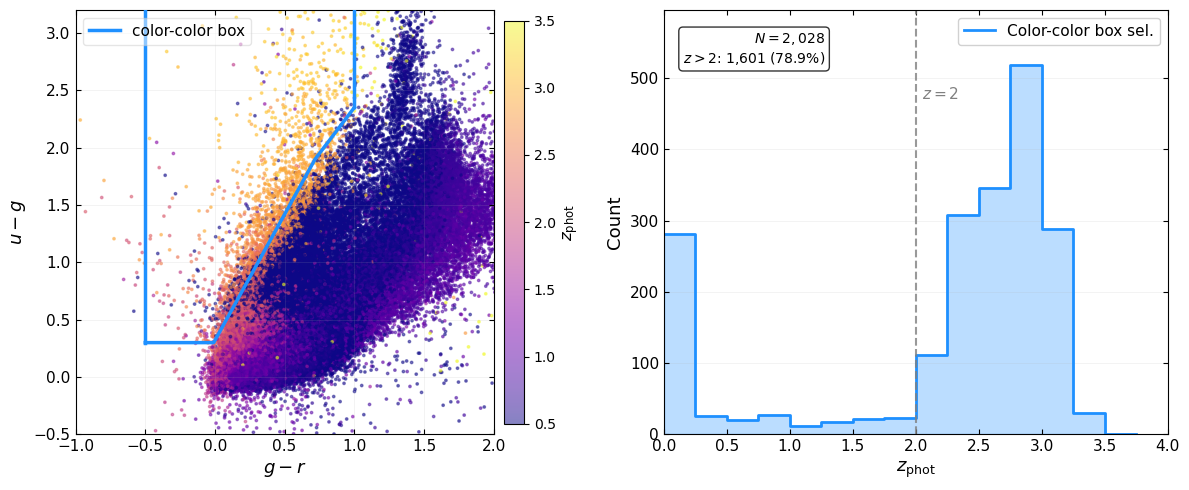

✓ Figure saved: ../images/cosmos_lbg_color_selection.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.table import Table

# =============================================================================
# Load COSMOS catalog
# =============================================================================
path_cosmos = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab = Table.read(path_cosmos, hdu=1)

# Extract columns
g = np.array(tab['g'], dtype=float)
r = np.array(tab['r'], dtype=float)
u = np.array(tab['u'], dtype=float)
u_err = np.array(tab['u_err'], dtype=float)
zphot = np.array(tab['ZPHOT'], dtype=float)
z_best = np.array(tab['Z_BEST'], dtype=float)
mask_flag = np.array(tab['MASK'])
flag_field = np.array(tab['FLAG_FIELD_BINARY'])
obj_type = np.array(tab['OBJ_TYPE'])

# Compute colors
g_r = g - r
u_g = u - g

# =============================================================================
# Selection criteria (common)
# =============================================================================
# Base selection: r-band cut, u_err cut, valid photometry, field flags
mask_base = (
    np.isfinite(g_r) & np.isfinite(u_g) &
    np.isfinite(zphot) & (zphot != -99) &
    np.isfinite(z_best) & (z_best != -99) &
    (r > 22.5) & (r < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

# Color-color box selection (u-dropout criteria)
cond_ug = u_g > 0.3
cond_gr = (g_r > -0.5) & (g_r < 1.0)
cond_diag = (u_g > (2.2*g_r + 0.32)) | ((u_g > (1.6*g_r + 0.75)) & (u_g > 0.9))

mask_box = mask_base & cond_ug & cond_gr & cond_diag

# Extract selected data
g_r_sel = g_r[mask_base]
u_g_sel = u_g[mask_base]
zphot_sel = zphot[mask_base]
z_box = zphot[mask_box]

print(f"Total sources: {len(tab):,}")
print(f"After base cuts: {mask_base.sum():,}")
print(f"Selected by color-color box: {mask_box. sum():,}")

# =============================================================================
# Compute color-cut boundary
# =============================================================================
g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([
    max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75)))
    for gr in g_r_line
])

# =============================================================================
# Create publication-quality figure (two panels, side by side)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# Left panel: Color-color diagram
# -----------------------------------------------------------------------------
ax1 = axes[0]

# Scatter plot with photo-z coloring
cmap = 'plasma'
norm = colors.Normalize(vmin=0.5, vmax=3.5)
sc = ax1.scatter(
    g_r_sel, u_g_sel, c=zphot_sel,
    cmap=cmap, norm=norm,
    s=3, alpha=0.5, rasterized=True
)

# Colorbar
cbar = fig.colorbar(sc, ax=ax1, pad=0.02, shrink=0.95)
cbar.set_label(r'$z_{\rm phot}$', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Color-cut boundary (blue polygon)
ax1.plot(g_r_line, lower_bound, color='dodgerblue', lw=2.5, 
         label='color-color box', zorder=5)
ax1.plot([-0.5, -0.5], [lower_bound[0], 3.5], color='dodgerblue', lw=2.5, zorder=5)
ax1.plot([1.0, 1.0], [lower_bound[-1], 3.5], color='dodgerblue', lw=2.5, zorder=5)
ax1.plot([-0.5, 1.0], [3.5, 3.5], color='dodgerblue', lw=2.5, zorder=5)

# Axis settings
ax1.set_xlim(-1.0, 2.0)
ax1.set_ylim(-0.5, 3.2)
ax1.set_xlabel(r'$g - r$', fontsize=13)
ax1.set_ylabel(r'$u - g$', fontsize=13)
ax1.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.5)
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# -----------------------------------------------------------------------------
# Right panel: Photo-z histogram of selected LBGs
# -----------------------------------------------------------------------------
ax2 = axes[1]

# Histogram settings
bins = np.arange(0, 4.25, 0.25)  # 0 to 4, step 0.25
counts, bin_edges = np.histogram(z_box, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

# Step histogram
ax2.step(bin_edges[:-1], counts, where='post', color='dodgerblue', lw=2, 
         label='Color-color box sel.')
ax2.fill_between(bin_edges[:-1], counts, step='post', alpha=0.3, color='dodgerblue')

# Reference line at z = 2 (LBG threshold)
ax2.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax2.text(2.05, ax2.get_ylim()[1]*0.9 if counts.max() > 0 else 10, 
         r'$z=2$', fontsize=11, color='gray', va='top')

# Axis settings
ax2.set_xlim(0, 4.0)
ax2.set_ylim(0, counts.max() * 1.15 if counts.max() > 0 else 10)
ax2.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax2.set_ylabel('Count', fontsize=13)
ax2.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')

# Statistics annotation
n_total = mask_box.sum()
n_z_gt_2 = np.sum(z_box > 2)
frac_z_gt_2 = n_z_gt_2 / n_total * 100 if n_total > 0 else 0
stats_text = (f'$N = {n_total:,}$\n'
              f'$z > 2$: {n_z_gt_2:,} ({frac_z_gt_2:.1f}%)')
ax2.text(0.32, 0.95, stats_text, transform=ax2.transAxes, fontsize=10,
         va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# -----------------------------------------------------------------------------
# Final layout
# -----------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('../images/cosmos_lbg_color_selection.png', dpi=600, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved: ../images/cosmos_lbg_color_selection.png")

## Training Data Building

### Cross matching Photometric and Spectroscopic Catalogs

In [3]:
import numpy as np
from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as unit

# =============================================================================
# Load catalogs
# =============================================================================
print("=" * 70)
print("LOADING CATALOGS")
print("=" * 70)

# COSMOS photometric catalog
path_phot = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab_phot = Table.read(path_phot, hdu=1)
print(f"Photometric catalog:  {len(tab_phot):,} sources")

# DESI spectroscopic catalog
path_spec = "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits"
tab_spec = Table.read(path_spec, hdu=1)
print(f"Spectroscopic catalog: {len(tab_spec):,} sources")

# =============================================================================
# Apply base selection to photometric catalog (same as before)
# =============================================================================
print("\n" + "=" * 70)
print("APPLYING BASE SELECTION TO PHOTOMETRIC CATALOG")
print("=" * 70)

# Extract columns
g = np.array(tab_phot['g'], dtype=float)
r = np.array(tab_phot['r'], dtype=float)
u = np.array(tab_phot['u'], dtype=float)
u_err = np.array(tab_phot['u_err'], dtype=float)
zphot = np.array(tab_phot['ZPHOT'], dtype=float)
z_best = np.array(tab_phot['Z_BEST'], dtype=float)
mask_flag = np.array(tab_phot['MASK'])
flag_field = np.array(tab_phot['FLAG_FIELD_BINARY'])
obj_type = np.array(tab_phot['OBJ_TYPE'])

# Compute colors
g_r = g - r
u_g = u - g

# Base selection mask
mask_base = (
    np.isfinite(g_r) & np.isfinite(u_g) &
    np.isfinite(zphot) & (zphot != -99) &
    np.isfinite(z_best) & (z_best != -99) &
    (r > 22.5) & (r < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

n_base = mask_base.sum()
print(f"Total photometric sources: {len(tab_phot):,}")
print(f"After base cuts: {n_base:,}")

# Get indices of selected sources
idx_phot_base = np.where(mask_base)[0]

# =============================================================================
# Coordinate matching
# =============================================================================
print("\n" + "=" * 70)
print("COORDINATE MATCHING")
print("=" * 70)

# Match radius
MATCH_RADIUS_ARCSEC = 1.0

# Photometric coordinates (base-selected)
ra_phot = np.array(tab_phot['RA'], dtype=float)[mask_base]
dec_phot = np.array(tab_phot['DEC'], dtype=float)[mask_base]
coords_phot = SkyCoord(ra=ra_phot * unit.deg, dec=dec_phot * unit.deg)

# Spectroscopic coordinates
ra_spec = np.array(tab_spec['TARGET_RA'], dtype=float)
dec_spec = np.array(tab_spec['TARGET_DEC'], dtype=float)
coords_spec = SkyCoord(ra=ra_spec * unit.deg, dec=dec_spec * unit.deg)

print(f"Photometric (base-selected): {len(coords_phot):,} sources")
print(f"Spectroscopic: {len(coords_spec):,} sources")
print(f"Match radius: {MATCH_RADIUS_ARCSEC} arcsec")

# -----------------------------------------------------------------------------
# Match 1: Photometric -> Spectroscopic (for each phot source, find nearest spec)
# -----------------------------------------------------------------------------
print("\n[1] Matching:  Photometric -> Spectroscopic")
idx_spec_match, sep_phot2spec, _ = match_coordinates_sky(coords_phot, coords_spec)
good_match_phot2spec = sep_phot2spec.arcsec < MATCH_RADIUS_ARCSEC

n_phot_matched = good_match_phot2spec.sum()
print(f"    Phot sources with spec match: {n_phot_matched:,} ({n_phot_matched/len(coords_phot)*100:.2f}%)")

# -----------------------------------------------------------------------------
# Match 2: Spectroscopic -> Photometric (for each spec source, find nearest phot)
# -----------------------------------------------------------------------------
print("\n[2] Matching:  Spectroscopic -> Photometric")
idx_phot_match, sep_spec2phot, _ = match_coordinates_sky(coords_spec, coords_phot)
good_match_spec2phot = sep_spec2phot.arcsec < MATCH_RADIUS_ARCSEC

n_spec_matched = good_match_spec2phot.sum()
print(f"    Spec sources with phot match: {n_spec_matched:,} ({n_spec_matched/len(coords_spec)*100:.2f}%)")

# =============================================================================
# Create masks for matched sources
# =============================================================================
print("\n" + "=" * 70)
print("CREATING MATCHED MASKS")
print("=" * 70)

# Mask for photometric catalog (base-selected, length = n_base)
# True if this phot source has a spec match within radius
mask_phot_matched = good_match_phot2spec  # length = n_base

# Mask for spectroscopic catalog (full, length = len(tab_spec))
# True if this spec source has a phot match within radius
mask_spec_matched = good_match_spec2phot  # length = len(tab_spec)

# Full photometric mask (length = len(tab_phot))
# True if source passes base cuts AND has spec match
mask_phot_full = np.zeros(len(tab_phot), dtype=bool)
mask_phot_full[idx_phot_base[mask_phot_matched]] = True

print(f"Photometric matched mask (base-selected): {mask_phot_matched.sum():,} / {len(mask_phot_matched):,}")
print(f"Spectroscopic matched mask:  {mask_spec_matched.sum():,} / {len(mask_spec_matched):,}")
print(f"Photometric matched mask (full catalog): {mask_phot_full.sum():,} / {len(tab_phot):,}")

# =============================================================================
# Get matched indices (for cross-referencing)
# =============================================================================
# For each matched phot source, the corresponding spec index
phot_to_spec_idx = idx_spec_match[mask_phot_matched]

# For each matched spec source, the corresponding phot index (within base-selected)
spec_to_phot_idx_base = idx_phot_match[mask_spec_matched]
# Convert to full photometric catalog index
spec_to_phot_idx_full = idx_phot_base[spec_to_phot_idx_base]

# =============================================================================
# Summary statistics
# =============================================================================
print("\n" + "=" * 70)
print("MATCHING SUMMARY")
print("=" * 70)

print(f"""
CATALOGS: 
  Photometric (total):         {len(tab_phot):,}
  Photometric (base-selected): {n_base:,}
  Spectroscopic (total):       {len(tab_spec):,}

MATCHING RESULTS (radius = {MATCH_RADIUS_ARCSEC} arcsec):
  Phot (base) with spec match: {n_phot_matched:,} ({n_phot_matched/n_base*100:.2f}% of base-selected)
  Spec with phot (base) match: {n_spec_matched:,} ({n_spec_matched/len(tab_spec)*100:.2f}% of spec catalog)

SEPARATION STATISTICS (matched sources):
  Phot->Spec: median = {np.median(sep_phot2spec[good_match_phot2spec].arcsec):.3f} arcsec
  Spec->Phot:  median = {np.median(sep_spec2phot[good_match_spec2phot].arcsec):.3f} arcsec
""")

# =============================================================================
# Return masks for further use
# =============================================================================
print("\n" + "=" * 70)
print("OUTPUT MASKS")
print("=" * 70)

print(f"""
Available masks for further analysis: 

1. mask_phot_matched (length = {len(mask_phot_matched):,})
   - Boolean mask for base-selected photometric sources
   - True if matched to spectroscopic catalog
   - Use:  tab_phot[mask_base][mask_phot_matched]

2. mask_spec_matched (length = {len(mask_spec_matched):,})
   - Boolean mask for spectroscopic catalog
   - True if matched to base-selected photometric sources
   - Use: tab_spec[mask_spec_matched]

3. mask_phot_full (length = {len(mask_phot_full):,})
   - Boolean mask for full photometric catalog
   - True if passes base cuts AND matched to spec
   - Use: tab_phot[mask_phot_full]

4. phot_to_spec_idx (length = {len(phot_to_spec_idx):,})
   - For each matched phot source, the index in spec catalog
   
5. spec_to_phot_idx_full (length = {len(spec_to_phot_idx_full):,})
   - For each matched spec source, the index in full phot catalog
""")

# =============================================================================
# Quick validation: show a few matched pairs
# =============================================================================
print("=" * 70)
print("SAMPLE MATCHED PAIRS (first 10)")
print("=" * 70)

n_show = min(10, n_phot_matched)
print(f"\n{'Phot_RA':>12} {'Phot_Dec':>12} {'Spec_RA':>12} {'Spec_Dec':>12} {'Sep(arcsec)':>12}")
print("-" * 65)

matched_phot_idx = np.where(mask_phot_matched)[0][: n_show]
for i in matched_phot_idx:
    spec_idx = idx_spec_match[i]
    sep = sep_phot2spec[i]. arcsec
    print(f"{ra_phot[i]:12.6f} {dec_phot[i]:12.6f} {ra_spec[spec_idx]: 12.6f} {dec_spec[spec_idx]:12.6f} {sep: 12.4f}")

LOADING CATALOGS
Photometric catalog:  5,263,013 sources
Spectroscopic catalog: 4,486 sources

APPLYING BASE SELECTION TO PHOTOMETRIC CATALOG
Total photometric sources: 5,263,013
After base cuts: 132,955

COORDINATE MATCHING
Photometric (base-selected): 132,955 sources
Spectroscopic: 4,486 sources
Match radius: 1.0 arcsec

[1] Matching:  Photometric -> Spectroscopic
    Phot sources with spec match: 1,519 (1.14%)

[2] Matching:  Spectroscopic -> Photometric
    Spec sources with phot match: 1,949 (43.45%)

CREATING MATCHED MASKS
Photometric matched mask (base-selected): 1,519 / 132,955
Spectroscopic matched mask:  1,949 / 4,486
Photometric matched mask (full catalog): 1,519 / 5,263,013

MATCHING SUMMARY

CATALOGS: 
  Photometric (total):         5,263,013
  Photometric (base-selected): 132,955
  Spectroscopic (total):       4,486

MATCHING RESULTS (radius = 1.0 arcsec):
  Phot (base) with spec match: 1,519 (1.14% of base-selected)
  Spec with phot (base) match: 1,949 (43.45% of spec ca

In [4]:
# =============================================================================
# Unique matching (one-to-one)
# =============================================================================
print("\n" + "=" * 70)
print("UNIQUE (ONE-TO-ONE) MATCHING ANALYSIS")
print("=" * 70)

# Method 1: Find unique spec indices matched from phot
spec_idx_matched_from_phot = idx_spec_match[mask_phot_matched]
unique_spec_idx, counts_spec = np.unique(spec_idx_matched_from_phot, return_counts=True)
n_unique_spec = len(unique_spec_idx)
n_multi_match_spec = np.sum(counts_spec > 1)

print(f"\n[1] From Phot→Spec matching:")
print(f"    Total matches: {mask_phot_matched.sum():,}")
print(f"    Unique spec sources matched: {n_unique_spec: ,}")
print(f"    Spec sources with multiple phot matches: {n_multi_match_spec:,}")

# Method 2: Find unique phot indices matched from spec
phot_idx_matched_from_spec = idx_phot_match[mask_spec_matched]
unique_phot_idx, counts_phot = np.unique(phot_idx_matched_from_spec, return_counts=True)
n_unique_phot = len(unique_phot_idx)
n_multi_match_phot = np.sum(counts_phot > 1)

print(f"\n[2] From Spec→Phot matching:")
print(f"    Total matches: {mask_spec_matched.sum():,}")
print(f"    Unique phot sources matched: {n_unique_phot:,}")
print(f"    Phot sources with multiple spec matches: {n_multi_match_phot:,}")

# =============================================================================
# Create strict one-to-one matching
# =============================================================================
# Keep only pairs where both directions agree (mutual nearest neighbors)

print(f"\n[3] Mutual nearest neighbor (strict one-to-one):")

# For a pair to be mutual: 
# - Phot[i] matches to Spec[j]  (idx_spec_match[i] = j)
# - Spec[j] matches back to Phot[i]  (idx_phot_match[j] = i)

mutual_mask_phot = np.zeros(len(mask_phot_matched), dtype=bool)

for i in range(len(mask_phot_matched)):
    if mask_phot_matched[i]:   # phot[i] has a spec match
        j = idx_spec_match[i]  # the matched spec index
        if mask_spec_matched[j]:  # spec[j] also has a phot match
            k = idx_phot_match[j]  # the phot index that spec[j] matches to
            if k == i:  # mutual match! 
                mutual_mask_phot[i] = True

n_mutual = mutual_mask_phot.sum()
print(f"    Mutual (one-to-one) matches: {n_mutual:,}")

# Create corresponding mask for spec catalog
mutual_spec_idx = idx_spec_match[mutual_mask_phot]
mutual_mask_spec = np.zeros(len(tab_spec), dtype=bool)
mutual_mask_spec[mutual_spec_idx] = True

print(f"\n[4] Final one-to-one masks:")
print(f"    mutual_mask_phot (base-selected): {mutual_mask_phot.sum():,}")
print(f"    mutual_mask_spec:  {mutual_mask_spec.sum():,}")


UNIQUE (ONE-TO-ONE) MATCHING ANALYSIS

[1] From Phot→Spec matching:
    Total matches: 1,519
    Unique spec sources matched:  1,511
    Spec sources with multiple phot matches: 7

[2] From Spec→Phot matching:
    Total matches: 1,949
    Unique phot sources matched: 1,511
    Phot sources with multiple spec matches: 438

[3] Mutual nearest neighbor (strict one-to-one):
    Mutual (one-to-one) matches: 1,511

[4] Final one-to-one masks:
    mutual_mask_phot (base-selected): 1,511
    mutual_mask_spec:  1,511


### Data Quality: CHI, ZPHOT and ZML_low&high.

DATA EXPLORATION FOR TRAINING SET DESIGN

Total base-selected:  132,955
  With spec match (mutual): 1,511
  Without spec match: 131,444

Photo-z based LBG (ZPHOT > 2):
  Total LBG: 7,408 (5.6%)
  Total non-LBG: 125,547

[1] CHI_BEST DISTRIBUTION
Valid CHI_BEST: 132,955 (100.0%)
  Min:  0.04
  Max:  2986.20
  Median: 5.22
  Percentiles: 10%=2.46, 50%=5.22, 90%=12.40

  LBG (z>2): median CHI_BEST = 9.19, N = 7,408
  Non-LBG:    median CHI_BEST = 5.01, N = 125,547

[2] PHOTO-Z UNCERTAINTY DISTRIBUTION
Valid z_err: 132,307
  Relative error (sigma_z / z_phot):
    Median: 0.052
    Percentiles: 10%=0.028, 50%=0.052, 90%=0.161

  LBG:  median rel_err = 0.039, N = 7,383
  Non-LBG: median rel_err = 0.052, N = 124,924

[3] SPEC-MATCHED vs NON-MATCHED COMPARISON

Spec-matched (1,511 sources):
  LBG (by ZPHOT): 1,213 (80.3%)
  Median CHI_BEST: 11.88

Non-spec (131,444 sources):
  LBG (by ZPHOT): 6,195 (4.7%)
  Median CHI_BEST: 5.18


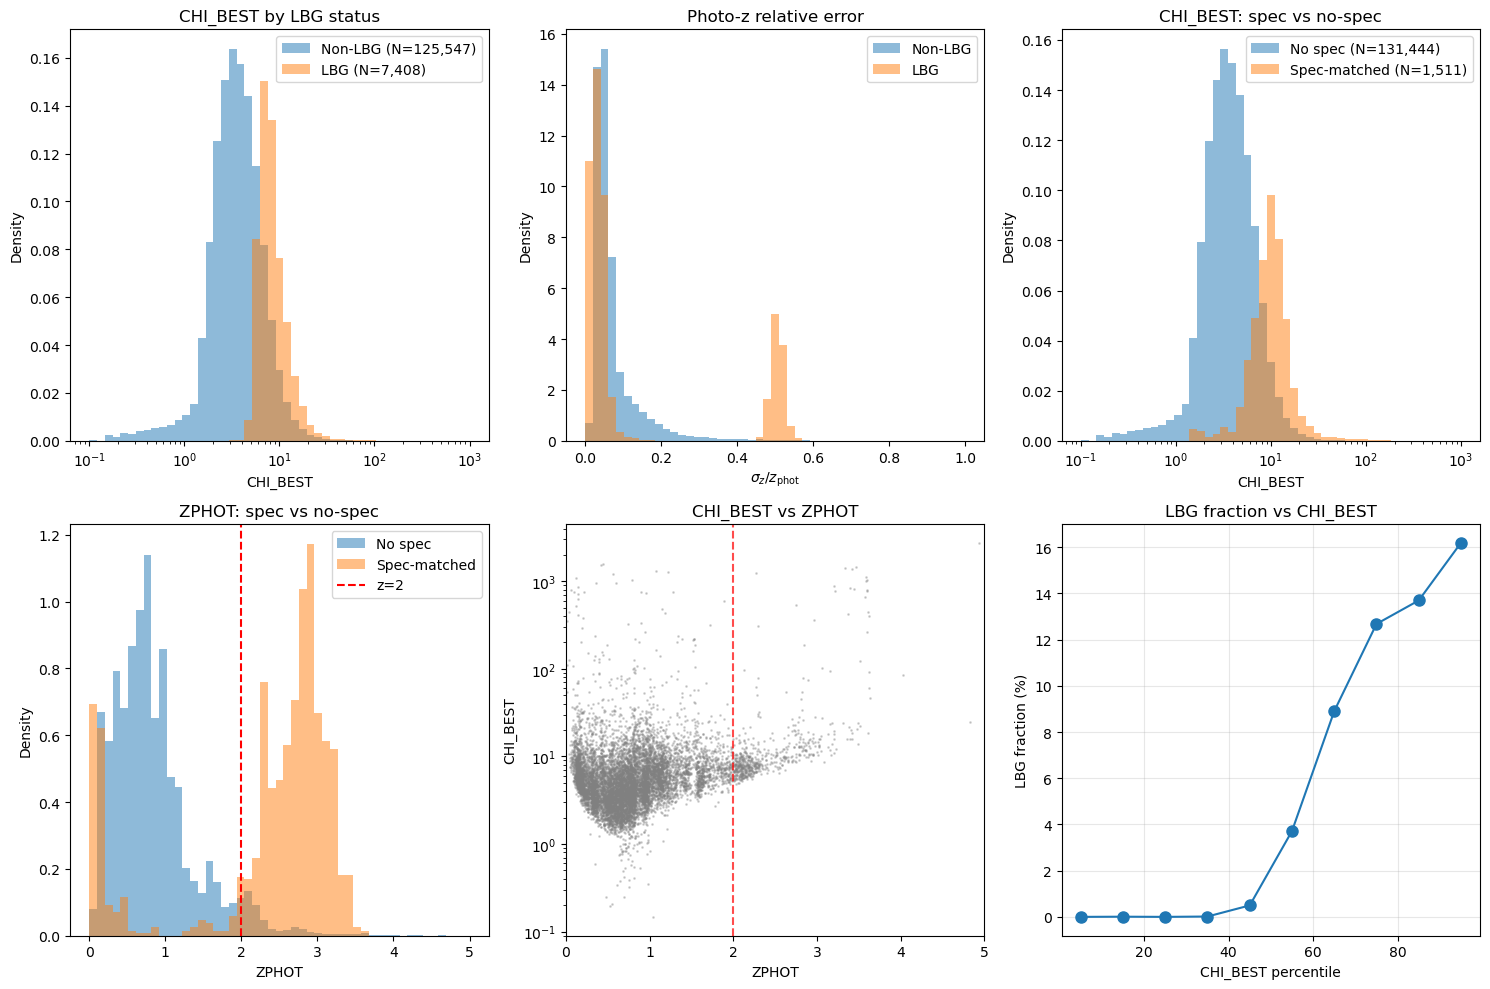


[4] CHI_BEST THRESHOLD ANALYSIS

 Threshold   N_selected      N_LBG   LBG_frac   N_nonLBG
-------------------------------------------------------
         5       62,609         31       0.0%     62,578
        10      111,829      3,912       3.5%    107,917
        20      126,426      5,463       4.3%    120,963
        50      129,738      5,761       4.4%    123,977
       100      130,375      5,838       4.5%    124,537


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# =============================================================================
# Load data and apply masks
# =============================================================================

# Get base-selected photometric data
tab_phot_base = tab_phot[mask_base]

# Extract relevant columns
zphot_base = np.array(tab_phot_base['ZPHOT'], dtype=float)
chi_best_base = np.array(tab_phot_base['CHI_BEST'], dtype=float)
z_ml68_low = np.array(tab_phot_base['Z_ML68_LOW'], dtype=float)
z_ml68_high = np. array(tab_phot_base['Z_ML68_HIGH'], dtype=float)

# Compute photo-z uncertainty (relative)
z_ml68_err = (z_ml68_high - z_ml68_low) / 2
z_ml68_rel_err = z_ml68_err / np.maximum(zphot_base, 0.01)  # relative error

# Define LBG by photo-z
is_lbg_photoz = zphot_base > 2.0

print("=" * 70)
print("DATA EXPLORATION FOR TRAINING SET DESIGN")
print("=" * 70)

print(f"\nTotal base-selected:  {len(tab_phot_base):,}")
print(f"  With spec match (mutual): {mutual_mask_phot.sum():,}")
print(f"  Without spec match: {(~mutual_mask_phot).sum():,}")

print(f"\nPhoto-z based LBG (ZPHOT > 2):")
print(f"  Total LBG: {is_lbg_photoz.sum():,} ({is_lbg_photoz.mean()*100:.1f}%)")
print(f"  Total non-LBG: {(~is_lbg_photoz).sum():,}")

# =============================================================================
# 1. Check CHI_BEST distribution
# =============================================================================
print("\n" + "=" * 70)
print("[1] CHI_BEST DISTRIBUTION")
print("=" * 70)

# Valid CHI_BEST
valid_chi = np.isfinite(chi_best_base) & (chi_best_base > 0) & (chi_best_base < 1e10)
print(f"Valid CHI_BEST: {valid_chi.sum():,} ({valid_chi.mean()*100:.1f}%)")

chi_valid = chi_best_base[valid_chi]
print(f"  Min:  {chi_valid.min():.2f}")
print(f"  Max:  {chi_valid.max():.2f}")
print(f"  Median: {np.median(chi_valid):.2f}")
print(f"  Percentiles: 10%={np.percentile(chi_valid, 10):.2f}, "
      f"50%={np.percentile(chi_valid, 50):.2f}, "
      f"90%={np.percentile(chi_valid, 90):.2f}")

# CHI_BEST by LBG status
chi_lbg = chi_best_base[valid_chi & is_lbg_photoz]
chi_nonlbg = chi_best_base[valid_chi & ~is_lbg_photoz]

print(f"\n  LBG (z>2): median CHI_BEST = {np. median(chi_lbg):.2f}, N = {len(chi_lbg):,}")
print(f"  Non-LBG:    median CHI_BEST = {np.median(chi_nonlbg):.2f}, N = {len(chi_nonlbg):,}")

# =============================================================================
# 2. Check photo-z uncertainty distribution
# =============================================================================
print("\n" + "=" * 70)
print("[2] PHOTO-Z UNCERTAINTY DISTRIBUTION")
print("=" * 70)

valid_zerr = np.isfinite(z_ml68_rel_err) & (z_ml68_rel_err > 0) & (z_ml68_rel_err < 10)
print(f"Valid z_err: {valid_zerr.sum():,}")

zerr_valid = z_ml68_rel_err[valid_zerr]
print(f"  Relative error (sigma_z / z_phot):")
print(f"    Median: {np.median(zerr_valid):.3f}")
print(f"    Percentiles: 10%={np.percentile(zerr_valid, 10):.3f}, "
      f"50%={np.percentile(zerr_valid, 50):.3f}, "
      f"90%={np.percentile(zerr_valid, 90):.3f}")

# By LBG status
zerr_lbg = z_ml68_rel_err[valid_zerr & is_lbg_photoz]
zerr_nonlbg = z_ml68_rel_err[valid_zerr & ~is_lbg_photoz]

print(f"\n  LBG:  median rel_err = {np.median(zerr_lbg):.3f}, N = {len(zerr_lbg):,}")
print(f"  Non-LBG: median rel_err = {np.median(zerr_nonlbg):.3f}, N = {len(zerr_nonlbg):,}")

# =============================================================================
# 3. Compare spec-matched vs non-matched
# =============================================================================
print("\n" + "=" * 70)
print("[3] SPEC-MATCHED vs NON-MATCHED COMPARISON")
print("=" * 70)

# Spec-matched sources
chi_spec = chi_best_base[mutual_mask_phot & valid_chi]
zphot_spec = zphot_base[mutual_mask_phot]
is_lbg_spec = zphot_spec > 2

# Non-spec sources
chi_nospec = chi_best_base[~mutual_mask_phot & valid_chi]
zphot_nospec = zphot_base[~mutual_mask_phot]
is_lbg_nospec = zphot_nospec > 2

print(f"\nSpec-matched ({mutual_mask_phot.sum():,} sources):")
print(f"  LBG (by ZPHOT): {is_lbg_spec.sum():,} ({is_lbg_spec.mean()*100:.1f}%)")
print(f"  Median CHI_BEST: {np.median(chi_spec):.2f}")

print(f"\nNon-spec ({(~mutual_mask_phot).sum():,} sources):")
print(f"  LBG (by ZPHOT): {is_lbg_nospec.sum():,} ({is_lbg_nospec.mean()*100:.1f}%)")
print(f"  Median CHI_BEST: {np.median(chi_nospec):.2f}")

# =============================================================================
# 4. Visualizations
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# (a) CHI_BEST distribution by LBG status
ax = axes[0, 0]
bins_chi = np.logspace(-1, 3, 50)
ax.hist(chi_nonlbg, bins=bins_chi, alpha=0.5, label=f'Non-LBG (N={len(chi_nonlbg):,})', density=True)
ax.hist(chi_lbg, bins=bins_chi, alpha=0.5, label=f'LBG (N={len(chi_lbg):,})', density=True)
ax.set_xscale('log')
ax.set_xlabel('CHI_BEST')
ax.set_ylabel('Density')
ax.set_title('CHI_BEST by LBG status')
ax.legend()

# (b) Photo-z relative error by LBG status
ax = axes[0, 1]
bins_err = np.linspace(0, 1, 50)
ax.hist(zerr_nonlbg[zerr_nonlbg < 1], bins=bins_err, alpha=0.5, label='Non-LBG', density=True)
ax.hist(zerr_lbg[zerr_lbg < 1], bins=bins_err, alpha=0.5, label='LBG', density=True)
ax.set_xlabel(r'$\sigma_z / z_{\rm phot}$')
ax.set_ylabel('Density')
ax.set_title('Photo-z relative error')
ax.legend()

# (c) CHI_BEST:  spec-matched vs non-matched
ax = axes[0, 2]
ax.hist(chi_nospec, bins=bins_chi, alpha=0.5, label=f'No spec (N={len(chi_nospec):,})', density=True)
ax.hist(chi_spec, bins=bins_chi, alpha=0.5, label=f'Spec-matched (N={len(chi_spec):,})', density=True)
ax.set_xscale('log')
ax.set_xlabel('CHI_BEST')
ax.set_ylabel('Density')
ax.set_title('CHI_BEST: spec vs no-spec')
ax.legend()

# (d) ZPHOT distribution by spec match
ax = axes[1, 0]
bins_z = np.linspace(0, 5, 50)
ax.hist(zphot_nospec[(zphot_nospec > 0) & (zphot_nospec < 5)], bins=bins_z, 
        alpha=0.5, label='No spec', density=True)
ax.hist(zphot_spec[(zphot_spec > 0) & (zphot_spec < 5)], bins=bins_z, 
        alpha=0.5, label='Spec-matched', density=True)
ax.axvline(2.0, color='red', linestyle='--', label='z=2')
ax.set_xlabel('ZPHOT')
ax.set_ylabel('Density')
ax.set_title('ZPHOT: spec vs no-spec')
ax.legend()

# (e) CHI_BEST vs ZPHOT scatter
ax = axes[1, 1]
sample_idx = np.random.choice(len(chi_best_base[valid_chi]), 
                               min(10000, valid_chi.sum()), replace=False)
ax.scatter(zphot_base[valid_chi][sample_idx], chi_best_base[valid_chi][sample_idx],
           s=1, alpha=0.3, c='gray')
ax.axvline(2.0, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('ZPHOT')
ax.set_ylabel('CHI_BEST')
ax.set_yscale('log')
ax.set_xlim(0, 5)
ax.set_title('CHI_BEST vs ZPHOT')

# (f) LBG fraction vs CHI_BEST percentile
ax = axes[1, 2]
chi_percentiles = np.percentile(chi_valid, np.arange(0, 101, 10))
lbg_fracs = []
for i in range(len(chi_percentiles) - 1):
    mask_bin = valid_chi & (chi_best_base >= chi_percentiles[i]) & (chi_best_base < chi_percentiles[i+1])
    if mask_bin.sum() > 0:
        lbg_frac = is_lbg_photoz[mask_bin].mean()
    else:
        lbg_frac = np.nan
    lbg_fracs.append(lbg_frac)
    
bin_centers = [(chi_percentiles[i] + chi_percentiles[i+1])/2 for i in range(len(chi_percentiles)-1)]
ax.plot(range(5, 100, 10), [f*100 for f in lbg_fracs], 'o-', markersize=8)
ax.set_xlabel('CHI_BEST percentile')
ax.set_ylabel('LBG fraction (%)')
ax.set_title('LBG fraction vs CHI_BEST')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/training_set_exploration.png', dpi=600, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. Suggested CHI_BEST threshold analysis
# =============================================================================
print("\n" + "=" * 70)
print("[4] CHI_BEST THRESHOLD ANALYSIS")
print("=" * 70)

thresholds = [5, 10, 20, 50, 100]

print(f"\n{'Threshold': >10} {'N_selected':>12} {'N_LBG':>10} {'LBG_frac':>10} {'N_nonLBG':>10}")
print("-" * 55)

for thresh in thresholds:
    mask_low_chi = valid_chi & (chi_best_base < thresh) & ~mutual_mask_phot
    n_sel = mask_low_chi.sum()
    n_lbg = (mask_low_chi & is_lbg_photoz).sum()
    n_nonlbg = (mask_low_chi & ~is_lbg_photoz).sum()
    lbg_frac = n_lbg / n_sel * 100 if n_sel > 0 else 0
    
    print(f"{thresh:>10} {n_sel:>12,} {n_lbg: >10,} {lbg_frac:>9.1f}% {n_nonlbg:>10,}")

## Training Strategy A

This is the baseline training strategy using all available spectroscopic redshifts as training labels.
- LBG (spec-z > 2):     ~1,213 (80.3%)
- Non-LBG (spec-z ≤ 2): ~298   (19.7%)

Since the spectroscopic sample is highly imbalanced, we cooperate with the label balance technique.

### Pipeline Implementation

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as unit
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

In [7]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================
print("=" * 70)
print("STEP 1: LOADING DATA")
print("=" * 70)

# Photometric catalog
path_phot = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab_phot = Table.read(path_phot, hdu=1)
print(f"Photometric catalog:  {len(tab_phot):,} sources")

# Spectroscopic catalog
path_spec = "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits"
tab_spec = Table.read(path_spec, hdu=1)
print(f"Spectroscopic catalog: {len(tab_spec):,} sources")

STEP 1: LOADING DATA
Photometric catalog:  5,263,013 sources
Spectroscopic catalog: 4,486 sources


In [8]:
# =============================================================================
# 2. APPLY BASE SELECTION
# =============================================================================
print("\n" + "=" * 70)
print("STEP 2: APPLYING BASE SELECTION")
print("=" * 70)

# Extract columns
u_mag = np.array(tab_phot['u'], dtype=float)
g_mag = np.array(tab_phot['g'], dtype=float)
r_mag = np.array(tab_phot['r'], dtype=float)
i_mag = np.array(tab_phot['i'], dtype=float)
z_mag = np.array(tab_phot['z'], dtype=float)
y_mag = np.array(tab_phot['y'], dtype=float)

u_err = np.array(tab_phot['u_err'], dtype=float)
g_err = np.array(tab_phot['g_err'], dtype=float)
r_err = np.array(tab_phot['r_err'], dtype=float)
i_err = np.array(tab_phot['i_err'], dtype=float)
z_err = np.array(tab_phot['z_err'], dtype=float)
y_err = np.array(tab_phot['y_err'], dtype=float)

zphot = np.array(tab_phot['ZPHOT'], dtype=float)
mask_flag = np.array(tab_phot['MASK'])
flag_field = np.array(tab_phot['FLAG_FIELD_BINARY'])
obj_type = np.array(tab_phot['OBJ_TYPE'])

# Compute colors
u_g = u_mag - g_mag
g_r = g_mag - r_mag
r_i = r_mag - i_mag
i_z = i_mag - z_mag
z_y = z_mag - y_mag

# Base selection mask
mask_base = (
    np.isfinite(u_g) & np.isfinite(g_r) & np.isfinite(r_i) &
    np.isfinite(i_z) & np.isfinite(z_y) & np.isfinite(i_mag) &
    np.isfinite(zphot) & (zphot != -99) &
    (r_mag > 22.5) & (r_mag < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

print(f"Total sources: {len(tab_phot):,}")
print(f"After base cuts: {mask_base.sum():,}")


STEP 2: APPLYING BASE SELECTION
Total sources: 5,263,013
After base cuts: 132,955


In [9]:
# =============================================================================
# 3. COORDINATE MATCHING
# =============================================================================
print("\n" + "=" * 70)
print("STEP 3: COORDINATE MATCHING (Phot <-> Spec)")
print("=" * 70)

MATCH_RADIUS_ARCSEC = 1.0

# Get base-selected indices
idx_phot_base = np.where(mask_base)[0]

# Coordinates
ra_phot = np.array(tab_phot['RA'], dtype=float)[mask_base]
dec_phot = np.array(tab_phot['DEC'], dtype=float)[mask_base]
coords_phot = SkyCoord(ra=ra_phot * unit.deg, dec=dec_phot * unit.deg)

ra_spec = np.array(tab_spec['TARGET_RA'], dtype=float)
dec_spec = np.array(tab_spec['TARGET_DEC'], dtype=float)
coords_spec = SkyCoord(ra=ra_spec * unit.deg, dec=dec_spec * unit.deg)

# Bidirectional matching
idx_spec_match, sep_phot2spec, _ = match_coordinates_sky(coords_phot, coords_spec)
good_match_phot2spec = sep_phot2spec.arcsec < MATCH_RADIUS_ARCSEC

idx_phot_match, sep_spec2phot, _ = match_coordinates_sky(coords_spec, coords_phot)
good_match_spec2phot = sep_spec2phot.arcsec < MATCH_RADIUS_ARCSEC

# Mutual (one-to-one) matching
mutual_mask_phot = np.zeros(mask_base.sum(), dtype=bool)
for i in range(len(mutual_mask_phot)):
    if good_match_phot2spec[i]:
        j = idx_spec_match[i]
        if good_match_spec2phot[j] and idx_phot_match[j] == i:
            mutual_mask_phot[i] = True

print(f"Mutual matches: {mutual_mask_phot.sum():,}")


STEP 3: COORDINATE MATCHING (Phot <-> Spec)
Mutual matches: 1,511


In [10]:
# =============================================================================
# 4. PREPARE TRAINING DATA (Spectroscopic sources only)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 4: PREPARING TRAINING DATA")
print("=" * 70)

# Get spectroscopic redshifts and quality flags
vi_z = np.array(tab_spec['VI_Z'], dtype=float)
vi_quality = np.array(tab_spec['VI_QUALITY'], dtype=float)
rr_z = np.array(tab_spec['RR_Z'], dtype=float)
rr_deltachi2 = np.array(tab_spec['RR_DELTACHI2'], dtype=float)

# For matched photometric sources, get corresponding spec indices
spec_idx_for_matched = idx_spec_match[mutual_mask_phot]

# Get spec-z for matched sources
vi_z_matched = vi_z[spec_idx_for_matched]
vi_quality_matched = vi_quality[spec_idx_for_matched]
rr_z_matched = rr_z[spec_idx_for_matched]
rr_deltachi2_matched = rr_deltachi2[spec_idx_for_matched]

# Define LBG label based on spectroscopic redshift
# (VI_QUALITY >= 2.5 & VI_Z > 2) OR (RR_DELTACHI2 > 9 & RR_Z > 2)
is_lbg_vi = (vi_quality_matched >= 2.5) & (vi_z_matched > 2.0)
is_lbg_rr = (rr_deltachi2_matched > 9) & (rr_z_matched > 2.0)
is_lbg_spec = (is_lbg_vi | is_lbg_rr).astype(int)

# Get best spec-z (prefer VI_Z if available)
spec_z_best = np.where(
    (vi_quality_matched >= 2.5) & np.isfinite(vi_z_matched),
    vi_z_matched,
    rr_z_matched
)

print(f"\nTraining set (spectroscopic sources):")
print(f"  Total: {mutual_mask_phot.sum():,}")
print(f"  LBG (spec-z > 2): {is_lbg_spec.sum():,} ({is_lbg_spec.mean()*100:.1f}%)")
print(f"  Non-LBG:  {(1 - is_lbg_spec).sum():,} ({(1-is_lbg_spec).mean()*100:.1f}%)")


STEP 4: PREPARING TRAINING DATA

Training set (spectroscopic sources):
  Total: 1,511
  LBG (spec-z > 2): 606 (40.1%)
  Non-LBG:  905 (59.9%)


In [11]:
# =============================================================================
# 5. BUILD FEATURE MATRIX
# =============================================================================
print("\n" + "=" * 70)
print("STEP 5: BUILDING FEATURE MATRIX")
print("=" * 70)

# Feature names
FEATURES = ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i',
            'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y']

# Build feature matrix for ALL base-selected sources
feature_data = {
    'u_g': u_g[mask_base],
    'g_r': g_r[mask_base],
    'r_i': r_i[mask_base],
    'i_z': i_z[mask_base],
    'z_y': z_y[mask_base],
    'mag_i': i_mag[mask_base],
    'err_u': u_err[mask_base],
    'err_g': g_err[mask_base],
    'err_r': r_err[mask_base],
    'err_i': i_err[mask_base],
    'err_z': z_err[mask_base],
    'err_y': y_err[mask_base],
}
df_features = pd.DataFrame(feature_data)

# Training set:  spectroscopic sources only
X_train = df_features.loc[mutual_mask_phot, FEATURES].values
y_train = is_lbg_spec

# Full evaluation set: all base-selected sources
X_all = df_features[FEATURES].values
zphot_all = zphot[mask_base]

print(f"Feature matrix shape: {X_all.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Features: {FEATURES}")

# Check for NaN
n_nan_train = np.isnan(X_train).sum()
n_nan_all = np.isnan(X_all).sum()
print(f"\nNaN in training set: {n_nan_train}")
print(f"NaN in full set: {n_nan_all}")


STEP 5: BUILDING FEATURE MATRIX
Feature matrix shape: (132955, 12)
Training set shape: (1511, 12)
Features: ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i', 'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y']

NaN in training set: 0
NaN in full set: 0


In [12]:
# =============================================================================
# 6. LIGHTGBM MODEL TRAINING
# =============================================================================
print("\n" + "=" * 70)
print("STEP 6: LIGHTGBM MODEL TRAINING")
print("=" * 70)

# LightGBM parameters (tuned for small, imbalanced dataset)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 15,           # Small to prevent overfitting
    'max_depth': 4,             # Shallow trees
    'learning_rate': 0.05,
    'n_estimators': 200,
    'min_child_samples': 20,    # Require more samples per leaf
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.5,           # Strong L1 regularization
    'reg_lambda': 0.5,          # Strong L2 regularization
    'is_unbalance': True,       # Handle class imbalance
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

# 5-Fold Cross-Validation
print("\n[1] 5-Fold Cross-Validation on training set...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {'auc': [], 'f1': [], 'precision': [], 'recall': []}
y_train_pred_cv = np.zeros(len(y_train))

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    # Train
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    model_cv = lgb.train(
        lgb_params,
        train_data,
        num_boost_round=200,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    
    # Predict
    y_val_pred = model_cv.predict(X_val)
    y_train_pred_cv[val_idx] = y_val_pred
    
    # Metrics
    auc = roc_auc_score(y_val, y_val_pred)
    f1 = f1_score(y_val, (y_val_pred >= 0.5).astype(int))
    prec = precision_score(y_val, (y_val_pred >= 0.5).astype(int))
    rec = recall_score(y_val, (y_val_pred >= 0.5).astype(int))
    
    cv_scores['auc'].append(auc)
    cv_scores['f1'].append(f1)
    cv_scores['precision'].append(prec)
    cv_scores['recall'].append(rec)
    
    print(f"  Fold {fold+1}:  AUC={auc:.4f}, F1={f1:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print(f"\nCV Results (mean ± std):")
print(f"  AUC:       {np.mean(cv_scores['auc']):.4f} ± {np.std(cv_scores['auc']):.4f}")
print(f"  F1:        {np.mean(cv_scores['f1']):.4f} ± {np.std(cv_scores['f1']):.4f}")
print(f"  Precision: {np.mean(cv_scores['precision']):.4f} ± {np.std(cv_scores['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_scores['recall']):.4f} ± {np.std(cv_scores['recall']):.4f}")

# [2] Train final model on all training data
print("\n[2] Training final model on all spectroscopic data...")
train_data_full = lgb.Dataset(X_train, label=y_train)
final_model = lgb.train(lgb_params, train_data_full, num_boost_round=150)

print(f"  Model trained with {final_model.num_trees()} trees")


STEP 6: LIGHTGBM MODEL TRAINING

[1] 5-Fold Cross-Validation on training set...


  Fold 1:  AUC=0.7421, F1=0.6548, Prec=0.5786, Rec=0.7541
  Fold 2:  AUC=0.7688, F1=0.6667, Prec=0.5793, Rec=0.7851
  Fold 3:  AUC=0.7580, F1=0.6562, Prec=0.6222, Rec=0.6942
  Fold 4:  AUC=0.7209, F1=0.6460, Prec=0.5529, Rec=0.7769
  Fold 5:  AUC=0.7394, F1=0.6360, Prec=0.5556, Rec=0.7438

CV Results (mean ± std):
  AUC:       0.7459 ± 0.0164
  F1:        0.6520 ± 0.0103
  Precision: 0.5777 ± 0.0249
  Recall:    0.7508 ± 0.0320

[2] Training final model on all spectroscopic data...
  Model trained with 200 trees


In [13]:
# =============================================================================
# 7. PREDICT ON FULL DATASET
# =============================================================================
print("\n" + "=" * 70)
print("STEP 7: PREDICTING ON FULL DATASET")
print("=" * 70)

# Predict probabilities
y_pred_all = final_model.predict(X_all)

# Classification at threshold
y_pred_class = (y_pred_all >= 0.75).astype(int)

# ML-selected LBGs
mask_ml_lbg = y_pred_class == 1
n_ml_lbg = mask_ml_lbg.sum()

print(f"Total base-selected sources: {len(y_pred_all):,}")
print(f"ML-predicted LBG: {n_ml_lbg:,} ({n_ml_lbg/len(y_pred_all)*100:.2f}%)")

# Photo-z distribution of ML-selected LBGs
zphot_ml_lbg = zphot_all[mask_ml_lbg]
print(f"\nML-selected LBG photo-z statistics:")
print(f"  Mean: {np.mean(zphot_ml_lbg):.3f}")
print(f"  Median: {np.median(zphot_ml_lbg):.3f}")
print(f"  z > 2: {(zphot_ml_lbg > 2).sum():,} ({(zphot_ml_lbg > 2).mean()*100:.1f}%)")


STEP 7: PREDICTING ON FULL DATASET
Total base-selected sources: 132,955
ML-predicted LBG: 1,553 (1.17%)

ML-selected LBG photo-z statistics:
  Mean: 1.342
  Median: 1.322
  z > 2: 411 (26.5%)


In [14]:
# =============================================================================
# 8. COLOR-COLOR BOX SELECTION (for comparison)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 8: COLOR-COLOR BOX SELECTION")
print("=" * 70)

# Color-color box criteria (u-dropout)
u_g_all = df_features['u_g'].values
g_r_all = df_features['g_r'].values

cond_ug = u_g_all > 0.3
cond_gr = (g_r_all > -0.5) & (g_r_all < 1.0)
cond_diag = u_g_all > np.maximum(np.maximum(2.2*g_r_all + 0.32, 1.6*g_r_all + 0.75), 0.9)

mask_box = cond_ug & cond_gr & cond_diag
n_box = mask_box.sum()

zphot_box = zphot_all[mask_box]

print(f"Color-box selected:  {n_box:,} ({n_box/len(y_pred_all)*100:.2f}%)")
print(f"\nColor-box selected photo-z statistics:")
print(f"  Mean: {np.mean(zphot_box):.3f}")
print(f"  Median: {np.median(zphot_box):.3f}")
print(f"  z > 2: {(zphot_box > 2).sum():,} ({(zphot_box > 2).mean()*100:.1f}%)")

# Overlap analysis
both_selected = mask_ml_lbg & mask_box
ml_only = mask_ml_lbg & ~mask_box
box_only = ~mask_ml_lbg & mask_box

print(f"\nOverlap Analysis:")
print(f"  Both methods:  {both_selected.sum():,}")
print(f"  ML only: {ml_only.sum():,}")
print(f"  Box only: {box_only.sum():,}")


STEP 8: COLOR-COLOR BOX SELECTION
Color-box selected:  1,008 (0.76%)

Color-box selected photo-z statistics:
  Mean: 2.551
  Median: 2.889
  z > 2: 851 (84.4%)

Overlap Analysis:
  Both methods:  226
  ML only: 1,327
  Box only: 782


In [15]:
# =============================================================================
# 9. FEATURE IMPORTANCE
# =============================================================================
print("\n" + "=" * 70)
print("STEP 9: FEATURE IMPORTANCE")
print("=" * 70)

importance = pd.DataFrame({
    'feature':  FEATURES,
    'importance':  final_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(importance.to_string(index=False))


STEP 9: FEATURE IMPORTANCE
feature  importance
    r_i 1783.142852
  err_r 1545.758524
    u_g 1523.318729
    g_r 1319.227605
  mag_i  987.156914
    i_z  857.989749
    z_y  832.745702
  err_y  499.671881
  err_u  419.797475
  err_z  392.586677
  err_g  366.488329
  err_i  175.272728



STEP 10: CREATING PUBLICATION-QUALITY FIGURES


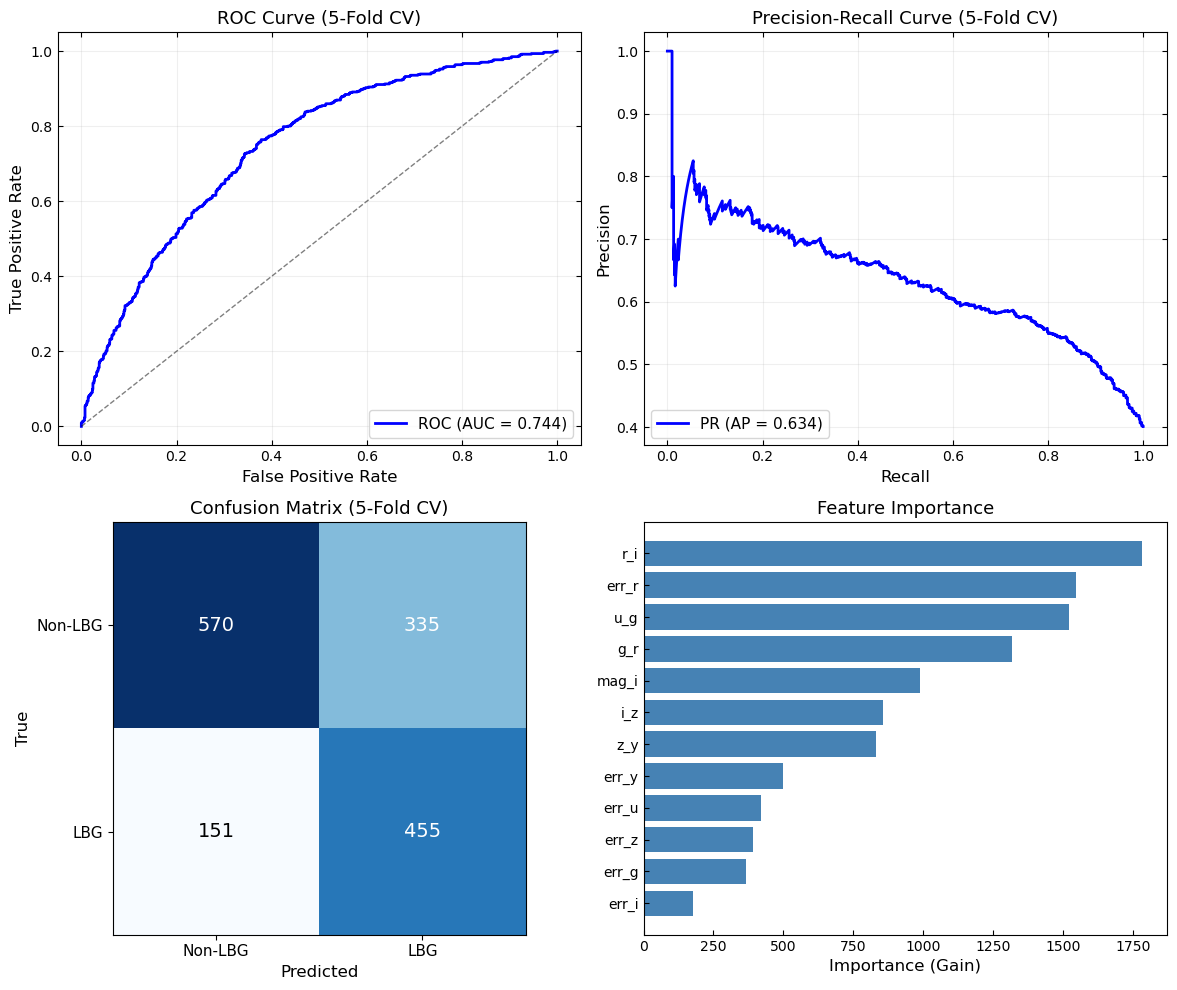

In [16]:
# =============================================================================
# 10. VISUALIZATION - PUBLICATION QUALITY
# =============================================================================
print("\n" + "=" * 70)
print("STEP 10: CREATING PUBLICATION-QUALITY FIGURES")
print("=" * 70)

# Figure 1: Model Evaluation (4 panels)
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))

# (a) ROC Curve
ax = axes1[0, 0]
fpr, tpr, _ = roc_curve(y_train, y_train_pred_cv)
auc_val = roc_auc_score(y_train, y_train_pred_cv)
ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve (5-Fold CV)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (b) Precision-Recall Curve
ax = axes1[0, 1]
prec_curve, rec_curve, _ = precision_recall_curve(y_train, y_train_pred_cv)
ap = average_precision_score(y_train, y_train_pred_cv)
ax.plot(rec_curve, prec_curve, 'b-', lw=2, label=f'PR (AP = {ap:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve (5-Fold CV)', fontsize=13)
ax.legend(loc='lower left', fontsize=11)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (c) Confusion Matrix
ax = axes1[1, 0]
y_train_pred_class = (y_train_pred_cv >= 0.5).astype(int)
cm = confusion_matrix(y_train, y_train_pred_class)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-LBG', 'LBG'], fontsize=11)
ax.set_yticklabels(['Non-LBG', 'LBG'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix (5-Fold CV)', fontsize=13)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

# (d) Feature Importance
ax = axes1[1, 1]
importance_sorted = importance.sort_values('importance', ascending=True)
ax.barh(importance_sorted['feature'], importance_sorted['importance'], color='steelblue')
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Feature Importance', fontsize=13)
ax.tick_params(axis='both', labelsize=10, direction='in')

plt.tight_layout()
plt.savefig('../images/model_evaluation_planA.png', dpi=600, bbox_inches='tight')
plt.show()

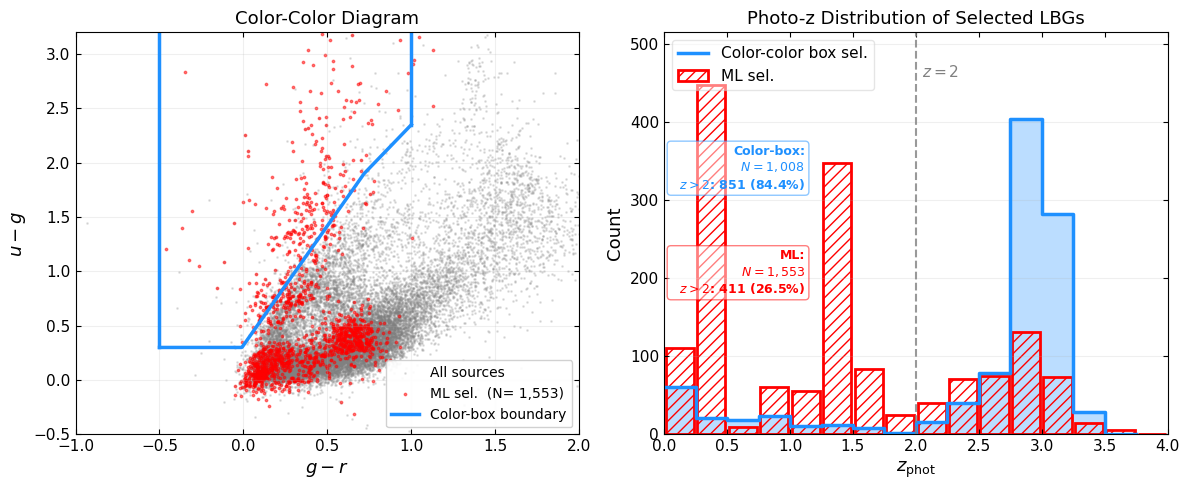

In [17]:
# -----------------------------------------------------------------------------
# Figure 2: ML vs Color-Box Comparison (KEY FIGURE)
# -----------------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# (a) Color-color diagram with both selections
ax = axes2[0]

# Background:  all sources (gray)
sample_idx = np.random.choice(len(g_r_all), min(20000, len(g_r_all)), replace=False)
ax.scatter(g_r_all[sample_idx], u_g_all[sample_idx], s=1, alpha=0.2, c='gray', 
           rasterized=True, label='All sources')

# ML-selected (red)
ax.scatter(g_r_all[mask_ml_lbg], u_g_all[mask_ml_lbg], s=3, alpha=0.5, c='red',
           rasterized=True, label=f'ML sel.  (N={n_ml_lbg: ,})')

# Color-box boundary
g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75))) 
                        for gr in g_r_line])
ax.plot(g_r_line, lower_bound, 'dodgerblue', lw=2.5, label='Color-box boundary')
ax.plot([-0.5, -0.5], [lower_bound[0], 3.5], 'dodgerblue', lw=2.5)
ax.plot([1.0, 1.0], [lower_bound[-1], 3.5], 'dodgerblue', lw=2.5)

ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-0.5, 3.2)
ax.set_xlabel(r'$g - r$', fontsize=13)
ax.set_ylabel(r'$u - g$', fontsize=13)
ax.set_title('Color-Color Diagram', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (b) Photo-z histogram comparison
ax = axes2[1]

bins = np.arange(0, 4.25, 0.25)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Color-box selection (blue step + fill)
counts_box, _ = np.histogram(zphot_box, bins=bins)
ax.step(bins[:-1], counts_box, where='post', color='dodgerblue', lw=2.5,
        label='Color-color box sel.')
ax.fill_between(bins[:-1], counts_box, step='post', alpha=0.3, color='dodgerblue')

# ML selection (red hatched)
counts_ml, _ = np.histogram(zphot_ml_lbg, bins=bins)
ax.bar(bin_centers, counts_ml, width=bin_width * 0.9, fill=False, 
       edgecolor='red', linewidth=2, hatch='///', label='ML sel.')

# Reference line at z = 2
y_max = max(counts_box. max(), counts_ml.max()) * 1.15
ax.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax.text(2.05, y_max * 0.92, r'$z=2$', fontsize=11, color='gray', va='top')

ax.set_xlim(0, 4.0)
ax.set_ylim(0, y_max)
ax.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Photo-z Distribution of Selected LBGs', fontsize=13)
ax.legend(loc='upper left', fontsize=11, framealpha=0.5)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2, axis='y')

# Statistics annotation - Color-box
n_box_z2 = (zphot_box > 2).sum()
frac_box_z2 = n_box_z2 / len(zphot_box) * 100 if len(zphot_box) > 0 else 0
stats_box = (f'Color-box:\n'
             f'  $N = {len(zphot_box):,}$\n'
             f'  $z > 2$: {n_box_z2:,} ({frac_box_z2:.1f}%)')

# Statistics annotation - ML
n_ml_z2 = (zphot_ml_lbg > 2).sum()
frac_ml_z2 = n_ml_z2 / len(zphot_ml_lbg) * 100 if len(zphot_ml_lbg) > 0 else 0
stats_ml = (f'ML:\n'
            f'  $N = {len(zphot_ml_lbg):,}$\n'
            f'  $z > 2$: {n_ml_z2:,} ({frac_ml_z2:.1f}%)')

ax.text(0.28, 0.72, stats_box, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='dodgerblue', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='dodgerblue'))
ax.text(0.28, 0.46, stats_ml, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='red'))

plt.tight_layout()
plt.savefig('../images/ml_vs_colorbox_planA.png', dpi=600, bbox_inches='tight')
plt.show()

In [18]:
# =============================================================================
# 11. SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("SUMMARY - PLAN A")
print("=" * 70)

print(f"""
TRAINING DATA: 
  Spectroscopic sources: {len(y_train):,}
  LBG:  {is_lbg_spec. sum():,} ({is_lbg_spec.mean()*100:.1f}%)
  Non-LBG: {(1-is_lbg_spec).sum():,} ({(1-is_lbg_spec).mean()*100:.1f}%)

CROSS-VALIDATION RESULTS:
  AUC:        {np.mean(cv_scores['auc']):.4f} ± {np.std(cv_scores['auc']):.4f}
  F1:        {np.mean(cv_scores['f1']):.4f} ± {np. std(cv_scores['f1']):.4f}
  Precision: {np.mean(cv_scores['precision']):.4f} ± {np.std(cv_scores['precision']):.4f}
  Recall:    {np.mean(cv_scores['recall']):.4f} ± {np.std(cv_scores['recall']):.4f}

PREDICTION ON FULL DATASET ({len(y_pred_all):,} sources):
  ML-selected LBG: {n_ml_lbg:,} ({n_ml_lbg/len(y_pred_all)*100:.2f}%)
    - z_phot > 2: {(zphot_ml_lbg > 2).sum():,} ({(zphot_ml_lbg > 2).mean()*100:.1f}%)
  
  Color-box LBG: {n_box: ,} ({n_box/len(y_pred_all)*100:.2f}%)
    - z_phot > 2: {(zphot_box > 2).sum():,} ({(zphot_box > 2).mean()*100:.1f}%)

COMPARISON: 
  Both methods: {both_selected.sum():,}
  ML only: {ml_only.sum():,}
  Box only: {box_only.sum():,}

SAVED FILES:
  ../images/model_evaluation_planA.png
  ../images/ml_vs_colorbox_planA.png
""")

print("=" * 70)
print("✓ PLAN A COMPLETE")
print("=" * 70)


SUMMARY - PLAN A

TRAINING DATA: 
  Spectroscopic sources: 1,511
  LBG:  606 (40.1%)
  Non-LBG: 905 (59.9%)

CROSS-VALIDATION RESULTS:
  AUC:        0.7459 ± 0.0164
  F1:        0.6520 ± 0.0103
  Precision: 0.5777 ± 0.0249
  Recall:    0.7508 ± 0.0320

PREDICTION ON FULL DATASET (132,955 sources):
  ML-selected LBG: 1,553 (1.17%)
    - z_phot > 2: 411 (26.5%)
  
  Color-box LBG:  1,008 (0.76%)
    - z_phot > 2: 851 (84.4%)

COMPARISON: 
  Both methods: 226
  ML only: 1,327
  Box only: 782

SAVED FILES:
  ../images/model_evaluation_planA.png
  ../images/ml_vs_colorbox_planA.png

✓ PLAN A COMPLETE


### Results and Evaluation

#### Model Performance

The LightGBM classifier trained exclusively on spectroscopic sources achieved moderate performance:
- **AUC = 0.746 ± 0.016**:  Indicates reasonable discriminative ability on the training set
- **Precision = 0.578**:  Relatively low, suggesting a high false positive rate
- **Recall = 0.751**: Acceptable, but ~25% of true LBGs are missed

#### Key Observations

**1. Spectroscopic Label Definition Issue**

The strict quality requirements for spectroscopic redshift confirmation (`VI_QUALITY ≥ 2.5` or `RR_DELTACHI2 > 9`) result in a conservative LBG definition. Many sources with $z_{\rm phot} > 2$ are classified as non-LBG in the training set due to: 
- Low signal-to-noise spectra that fail quality cuts
- Ambiguous spectral features at high redshift
- Incomplete spectral coverage

This creates a **label mismatch** between the training set (spec-z based) and evaluation set (photo-z based).

**2. Poor Generalization to Photo-z Domain**

| Method | N Selected | $z_{\rm phot} > 2$ | Purity |
|:-------|:-----------|:-------------------|:-------|
| Color-box | 1,008 | 851 | **84.4%** |
| ML (Plan A) | 1,553 | 411 | **26.5%** |

The ML model selects **more sources but with significantly lower purity**. The photo-z distribution shows ML-selected LBGs are predominantly at $z_{\rm phot} < 2$, indicating the model learned features that do not effectively distinguish high-redshift galaxies. 

**3. Feature Importance Insights**

The top features (`r_i`, `err_r`, `u_g`, `g_r`) are physically relevant for LBG selection, particularly the $u-g$ color which traces the Lyman break. However, the model appears to over-rely on photometric errors, which may correlate with spectroscopic quality rather than true redshift.

#### Conclusion

**Plan A is insufficient** for reliable LBG selection. The fundamental problem is the discrepancy between spectroscopic quality-based labels and photometric redshift-based evaluation. The model learns to identify sources with good spectroscopic measurements rather than genuine high-redshift galaxies. 

## Training Strategy B

This strategy focuses on training the model using only high-quality photo redshifts as labels, avoiding the pitfalls of spectroscopic label definitions. 

### Pipeline Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.table import Table
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as unit
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================
print("=" * 70)
print("PLAN B: HIGH-QUALITY PHOTO-Z TRAINING")
print("=" * 70)

# Photometric catalog
path_phot = "../data_Clauds/COSMOS_6bands-SExtractor-Lephare.fits"
tab_phot = Table.read(path_phot, hdu=1)
print(f"\nPhotometric catalog: {len(tab_phot):,} sources")

# Spectroscopic catalog
path_spec = "../CLAUDS_udrop_specz/COSMOS_udrop_specz.fits"
tab_spec = Table.read(path_spec, hdu=1)
print(f"Spectroscopic catalog: {len(tab_spec):,} sources")

PLAN B: HIGH-QUALITY PHOTO-Z TRAINING

Photometric catalog: 5,263,013 sources
Spectroscopic catalog: 4,486 sources


In [3]:
# =============================================================================
# 2. APPLY BASE SELECTION
# =============================================================================
print("\n" + "=" * 70)
print("STEP 1: APPLYING BASE SELECTION")
print("=" * 70)

# Extract photometric columns
u_mag = np.array(tab_phot['u'], dtype=float)
g_mag = np.array(tab_phot['g'], dtype=float)
r_mag = np.array(tab_phot['r'], dtype=float)
i_mag = np.array(tab_phot['i'], dtype=float)
z_mag = np.array(tab_phot['z'], dtype=float)
y_mag = np.array(tab_phot['y'], dtype=float)

u_err = np.array(tab_phot['u_err'], dtype=float)
g_err = np.array(tab_phot['g_err'], dtype=float)
r_err = np.array(tab_phot['r_err'], dtype=float)
i_err = np.array(tab_phot['i_err'], dtype=float)
z_err = np.array(tab_phot['z_err'], dtype=float)
y_err = np.array(tab_phot['y_err'], dtype=float)

zphot = np.array(tab_phot['ZPHOT'], dtype=float)
z_ml68_low = np.array(tab_phot['Z_ML68_LOW'], dtype=float)
z_ml68_high = np.array(tab_phot['Z_ML68_HIGH'], dtype=float)

mask_flag = np.array(tab_phot['MASK'])
flag_field = np.array(tab_phot['FLAG_FIELD_BINARY'])
obj_type = np.array(tab_phot['OBJ_TYPE'])

# Compute colors
u_g = u_mag - g_mag
g_r = g_mag - r_mag
r_i = r_mag - i_mag
i_z = i_mag - z_mag
z_y = z_mag - y_mag

# Photo-z uncertainty (relative)
z_err_half = (z_ml68_high - z_ml68_low) / 2.0
z_rel_err = z_err_half / np.maximum(zphot, 0.001)

# Base selection mask
mask_base = (
    np.isfinite(u_g) & np.isfinite(g_r) & np.isfinite(r_i) &
    np.isfinite(i_z) & np.isfinite(z_y) & np.isfinite(i_mag) &
    np.isfinite(zphot) & (zphot != -99) &
    (r_mag > 22.5) & (r_mag < 23.75) &
    np.isfinite(u_err) & (u_err < 1) &
    (obj_type == 0) &
    (mask_flag == 0) &
    flag_field[:, 0].astype(bool) &
    flag_field[:, 1].astype(bool)
)

print(f"Total sources: {len(tab_phot):,}")
print(f"After base cuts: {mask_base.sum():,}")


STEP 1: APPLYING BASE SELECTION
Total sources: 5,263,013
After base cuts: 132,955


In [4]:
# =============================================================================
# 3. BUILD FEATURE MATRIX FOR ALL BASE-SELECTED SOURCES
# =============================================================================
print("\n" + "=" * 70)
print("STEP 2: BUILDING FEATURE MATRIX")
print("=" * 70)

FEATURES = ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i',
            'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y']

# Feature matrix for ALL base-selected sources
feature_data = {
    'u_g': u_g[mask_base],
    'g_r': g_r[mask_base],
    'r_i': r_i[mask_base],
    'i_z': i_z[mask_base],
    'z_y': z_y[mask_base],
    'mag_i': i_mag[mask_base],
    'err_u': u_err[mask_base],
    'err_g': g_err[mask_base],
    'err_r': r_err[mask_base],
    'err_i': i_err[mask_base],
    'err_z': z_err[mask_base],
    'err_y': y_err[mask_base],
}
df_all = pd.DataFrame(feature_data)
df_all['zphot'] = zphot[mask_base]
df_all['z_rel_err'] = z_rel_err[mask_base]

# LBG label based on ZPHOT
df_all['is_lbg'] = (df_all['zphot'] > 2.0).astype(int)

print(f"Total base-selected:  {len(df_all):,}")
print(f"  LBG (ZPHOT > 2): {df_all['is_lbg'].sum():,} ({df_all['is_lbg'].mean()*100:.2f}%)")
print(f"  Non-LBG: {(1 - df_all['is_lbg']).sum():,}")


STEP 2: BUILDING FEATURE MATRIX
Total base-selected:  132,955
  LBG (ZPHOT > 2): 7,408 (5.57%)
  Non-LBG: 125,547


In [5]:
# =============================================================================
# 4. HIGH-QUALITY SUBSET SELECTION
# =============================================================================
QUALITY_THRESHOLD = 0.05
print("\n" + "=" * 70)
print("STEP 3: HIGH-QUALITY SUBSET")
print("=" * 70)

# High-quality mask
mask_hq = (df_all['z_rel_err'] < QUALITY_THRESHOLD) & np.isfinite(df_all['z_rel_err'])
print(f"High-quality mask: σ_z/z < {QUALITY_THRESHOLD}")

df_hq = df_all[mask_hq]. copy().reset_index(drop=True)

print(f"High-quality sources: {len(df_hq):,} ({len(df_hq)/len(df_all)*100:.1f}%)")
print(f"  LBG:  {df_hq['is_lbg'].sum():,} ({df_hq['is_lbg'].mean()*100:.2f}%)")
print(f"  Non-LBG: {(1 - df_hq['is_lbg']).sum():,}")


STEP 3: HIGH-QUALITY SUBSET
High-quality mask: σ_z/z < 0.05
High-quality sources: 62,634 (47.1%)
  LBG:  4,751 (7.59%)
  Non-LBG: 57,883


In [6]:
# =============================================================================
# 5. TRAIN/TEST SPLIT (70/30)
# =============================================================================
print("\n" + "=" * 70)
print("STEP 4: TRAIN/TEST SPLIT")
print("=" * 70)

X_hq = df_hq[FEATURES].values
y_hq = df_hq['is_lbg'].values
test_size = 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X_hq, y_hq, test_size=test_size, stratify=y_hq, random_state=42
)

print(f"Train/Test split: {100*(1 - test_size):.0f}% / {100*test_size:.0f}%")
print(f"Training set:  {len(X_train):,}")
print(f"  LBG: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test set: {len(X_test):,}")
print(f"  LBG: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


STEP 4: TRAIN/TEST SPLIT
Train/Test split: 70% / 30%
Training set:  43,843
  LBG: 3,326 (7.59%)
Test set: 18,791
  LBG: 1,425 (7.58%)


In [16]:
# =============================================================================
# 6. LIGHTGBM TRAINING
# =============================================================================
print("\n" + "=" * 70)
print("STEP 5: LIGHTGBM TRAINING")
print("=" * 70)

# Optimized parameters for larger dataset
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': 6,
    'learning_rate': 0.03,
    'n_estimators': 500,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'is_unbalance': True,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

# 5-Fold Cross-Validation on training set
print("\n[1] 5-Fold Cross-Validation...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {'auc': [], 'f1': [], 'precision': [], 'recall': []}
y_train_pred_cv = np.zeros(len(y_train))

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    model_cv = lgb.train(
        lgb_params,
        train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    y_val_pred = model_cv.predict(X_val)
    y_train_pred_cv[val_idx] = y_val_pred
    
    auc = roc_auc_score(y_val, y_val_pred)
    f1 = f1_score(y_val, (y_val_pred >= 0.5).astype(int))
    prec = precision_score(y_val, (y_val_pred >= 0.5).astype(int))
    rec = recall_score(y_val, (y_val_pred >= 0.5).astype(int))
    
    cv_scores['auc'].append(auc)
    cv_scores['f1'].append(f1)
    cv_scores['precision'].append(prec)
    cv_scores['recall'].append(rec)
    
    print(f"  Fold {fold+1}:  AUC={auc:.4f}, F1={f1:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")

print(f"\nCV Results (mean ± std):")
print(f"  AUC:       {np.mean(cv_scores['auc']):.4f} ± {np.std(cv_scores['auc']):.4f}")
print(f"  F1:        {np.mean(cv_scores['f1']):.4f} ± {np.std(cv_scores['f1']):.4f}")
print(f"  Precision: {np.mean(cv_scores['precision']):.4f} ± {np.std(cv_scores['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_scores['recall']):.4f} ± {np.std(cv_scores['recall']):.4f}")

# [2] Train final model
print("\n[2] Training final model...")
train_data_full = lgb.Dataset(X_train, label=y_train)
final_model = lgb.train(lgb_params, train_data_full, num_boost_round=300)
print(f"  Model trained with {final_model.num_trees()} trees")

# [3] Evaluate on test set
prob_thresh = 0.99985
print("\n[3] Evaluating on test set...")
print(f"Probability Threshold: {prob_thresh}")
y_test_pred = final_model.predict(X_test)
y_test_class = (y_test_pred >= prob_thresh).astype(int)

test_auc = roc_auc_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_class)
test_prec = precision_score(y_test, y_test_class)
test_rec = recall_score(y_test, y_test_class)

print(f"  Test AUC:       {test_auc:.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Test Precision: {test_prec:.4f}")
print(f"  Test Recall:    {test_rec:.4f}")


STEP 5: LIGHTGBM TRAINING

[1] 5-Fold Cross-Validation...
  Fold 1:  AUC=0.9954, F1=0.9167, Prec=0.8703, Rec=0.9684
  Fold 2:  AUC=0.9962, F1=0.9495, Prec=0.9383, Rec=0.9609
  Fold 3:  AUC=0.9971, F1=0.9163, Prec=0.8623, Rec=0.9775
  Fold 4:  AUC=0.9942, F1=0.9374, Prec=0.9083, Rec=0.9684
  Fold 5:  AUC=0.9961, F1=0.9490, Prec=0.9462, Rec=0.9519

CV Results (mean ± std):
  AUC:       0.9958 ± 0.0010
  F1:        0.9338 ± 0.0148
  Precision: 0.9051 ± 0.0342
  Recall:    0.9654 ± 0.0086

[2] Training final model...
  Model trained with 500 trees

[3] Evaluating on test set...
Probability Threshold: 0.99985
  Test AUC:       0.9951
  Test F1:        0.3583
  Test Precision: 1.0000
  Test Recall:    0.2182


In [17]:
# =============================================================================
# 7. PREDICT ON FULL DATASET
# =============================================================================
print("\n" + "=" * 70)
print("STEP 6: PREDICTING ON FULL DATASET")
print("=" * 70)

X_all = df_all[FEATURES].values
y_pred_all = final_model.predict(X_all)
y_pred_class_all = (y_pred_all >= prob_thresh).astype(int)

# ML-selected LBGs
mask_ml_lbg = y_pred_class_all == 1
n_ml_lbg = mask_ml_lbg.sum()
zphot_all = df_all['zphot']. values
zphot_ml_lbg = zphot_all[mask_ml_lbg]

print(f"Total sources: {len(y_pred_all):,}")
print(f"ML-predicted LBG: {n_ml_lbg:,} ({n_ml_lbg/len(y_pred_all)*100:.2f}%)")
print(f"z_phot > 2: {(zphot_ml_lbg > 2).sum():,} ({(zphot_ml_lbg > 2).mean()*100:.1f}%)")


STEP 6: PREDICTING ON FULL DATASET
Total sources: 132,955
ML-predicted LBG: 2,006 (1.51%)
z_phot > 2: 1,551 (77.3%)


In [18]:
# =============================================================================
# 8. COLOR-COLOR BOX SELECTION
# =============================================================================
print("\n" + "=" * 70)
print("STEP 7: COLOR-COLOR BOX SELECTION")
print("=" * 70)

u_g_all = df_all['u_g']. values
g_r_all = df_all['g_r']. values

# Color-color box criteria (u-dropout) - CORRECTED to match original
cond_ug = u_g_all > 0.3
cond_gr = (g_r_all > -0.5) & (g_r_all < 1.0)
# Original condition: (u-g > 2.2*(g-r) + 0.32) OR ((u-g > 1.6*(g-r) + 0.75) AND (u-g > 0.9))
cond_diag = (u_g_all > (2.2*g_r_all + 0.32)) | ((u_g_all > (1.6*g_r_all + 0.75)) & (u_g_all > 0.9))

mask_box = cond_ug & cond_gr & cond_diag
n_box = mask_box.sum()
zphot_box = zphot_all[mask_box]

print(f"Color-box selected: {n_box:,} ({n_box/len(y_pred_all)*100:.2f}%)")
print(f"z_phot > 2: {(zphot_box > 2).sum():,} ({(zphot_box > 2).mean()*100:.1f}%)")

# Overlap analysis
both_selected = mask_ml_lbg & mask_box
ml_only = mask_ml_lbg & ~mask_box
box_only = ~mask_ml_lbg & mask_box

print(f"\nOverlap Analysis:")
print(f"  Both methods:  {both_selected.sum():,}")
print(f"  ML only: {ml_only.sum():,}")
print(f"  Box only: {box_only. sum():,}")


STEP 7: COLOR-COLOR BOX SELECTION
Color-box selected: 2,028 (1.53%)
z_phot > 2: 1,601 (78.9%)

Overlap Analysis:
  Both methods:  997
  ML only: 1,009
  Box only: 1,031


In [19]:
# =============================================================================
# 9. SPECTROSCOPIC VALIDATION
# =============================================================================
print("\n" + "=" * 70)
print("STEP 8: SPECTROSCOPIC VALIDATION")
print("=" * 70)

# Coordinate matching
MATCH_RADIUS_ARCSEC = 1.0

idx_phot_base = np.where(mask_base)[0]
ra_phot = np.array(tab_phot['RA'], dtype=float)[mask_base]
dec_phot = np.array(tab_phot['DEC'], dtype=float)[mask_base]
coords_phot = SkyCoord(ra=ra_phot * unit.deg, dec=dec_phot * unit.deg)

ra_spec = np.array(tab_spec['TARGET_RA'], dtype=float)
dec_spec = np.array(tab_spec['TARGET_DEC'], dtype=float)
coords_spec = SkyCoord(ra=ra_spec * unit.deg, dec=dec_spec * unit.deg)
# Bidirectional matching
idx_spec_match, sep_phot2spec, _ = match_coordinates_sky(coords_phot, coords_spec)
good_match_phot2spec = sep_phot2spec. arcsec < MATCH_RADIUS_ARCSEC

idx_phot_match, sep_spec2phot, _ = match_coordinates_sky(coords_spec, coords_phot)
good_match_spec2phot = sep_spec2phot.arcsec < MATCH_RADIUS_ARCSEC

# Mutual matching
mutual_mask_phot = np.zeros(mask_base.sum(), dtype=bool)
for i in range(len(mutual_mask_phot)):
    if good_match_phot2spec[i]:
        j = idx_spec_match[i]
        if good_match_spec2phot[j] and idx_phot_match[j] == i:
            mutual_mask_phot[i] = True

print(f"Spectroscopic matches: {mutual_mask_phot.sum():,}")

# Get spectroscopic data for matched sources
spec_idx_matched = idx_spec_match[mutual_mask_phot]
vi_z = np.array(tab_spec['VI_Z'], dtype=float)[spec_idx_matched]
vi_quality = np.array(tab_spec['VI_QUALITY'], dtype=float)[spec_idx_matched]
rr_z = np.array(tab_spec['RR_Z'], dtype=float)[spec_idx_matched]
rr_deltachi2 = np.array(tab_spec['RR_DELTACHI2'], dtype=float)[spec_idx_matched]

# Get best spec-z
spec_z_best = np.where(
    (vi_quality >= 2.5) & np.isfinite(vi_z),
    vi_z,
    rr_z
)

# ML predictions for spec-matched sources
y_pred_spec = y_pred_all[mutual_mask_phot]
y_pred_class_spec = (y_pred_spec >= 0.5).astype(int)

# Version 1: No quality control (spec_z > 2)
print("\n[Version 1] Spec-z > 2 (no quality control):")
is_lbg_spec_v1 = (spec_z_best > 2.0).astype(int)
valid_v1 = np.isfinite(spec_z_best) & (spec_z_best > 0)

if valid_v1.sum() > 0:
    auc_v1 = roc_auc_score(is_lbg_spec_v1[valid_v1], y_pred_spec[valid_v1])
    y_pred_v1 = y_pred_class_spec[valid_v1]
    y_true_v1 = is_lbg_spec_v1[valid_v1]
    
    print(f"  Valid sources: {valid_v1.sum():,}")
    print(f"  True LBG (spec-z > 2): {y_true_v1.sum():,}")
    print(f"  Predicted LBG:  {y_pred_v1.sum():,}")
    print(f"  AUC: {auc_v1:.4f}")
    print(f"  Precision: {precision_score(y_true_v1, y_pred_v1):.4f}")
    print(f"  Recall: {recall_score(y_true_v1, y_pred_v1):.4f}")
    print(f"  F1: {f1_score(y_true_v1, y_pred_v1):.4f}")

# Version 2: With quality control
print("\n[Version 2] High-quality spec-z > 2 (VI_Q >= 2.5 | RR_DELTACHI2 > 9):")
is_lbg_vi = (vi_quality >= 2.5) & (vi_z > 2.0)
is_lbg_rr = (rr_deltachi2 > 9) & (rr_z > 2.0)
is_lbg_spec_v2 = (is_lbg_vi | is_lbg_rr).astype(int)

# For non-LBG:  require quality confirmation too
is_nonlbg_vi = (vi_quality >= 2.5) & (vi_z <= 2.0) & np.isfinite(vi_z)
is_nonlbg_rr = (rr_deltachi2 > 9) & (rr_z <= 2.0) & np.isfinite(rr_z)
is_nonlbg_spec_v2 = is_nonlbg_vi | is_nonlbg_rr

# Only keep sources with quality measurements
valid_v2 = (is_lbg_vi | is_lbg_rr | is_nonlbg_vi | is_nonlbg_rr)
y_true_v2 = is_lbg_spec_v2[valid_v2]
y_pred_v2 = y_pred_class_spec[valid_v2]
y_prob_v2 = y_pred_spec[valid_v2]

if valid_v2.sum() > 0:
    auc_v2 = roc_auc_score(y_true_v2, y_prob_v2)
    print(f"  Valid sources: {valid_v2.sum():,}")
    print(f"  True LBG:  {y_true_v2.sum():,}")
    print(f"  Predicted LBG: {y_pred_v2.sum():,}")
    print(f"  AUC:  {auc_v2:.4f}")
    print(f"  Precision: {precision_score(y_true_v2, y_pred_v2):.4f}")
    print(f"  Recall: {recall_score(y_true_v2, y_pred_v2):.4f}")
    print(f"  F1: {f1_score(y_true_v2, y_pred_v2):.4f}")


STEP 8: SPECTROSCOPIC VALIDATION
Spectroscopic matches: 1,511

[Version 1] Spec-z > 2 (no quality control):
  Valid sources: 1,503
  True LBG (spec-z > 2): 677
  Predicted LBG:  1,445
  AUC: 0.6298
  Precision: 0.4595
  Recall: 0.9808
  F1: 0.6258

[Version 2] High-quality spec-z > 2 (VI_Q >= 2.5 | RR_DELTACHI2 > 9):
  Valid sources: 1,199
  True LBG:  606
  Predicted LBG: 1,151
  AUC:  0.6551
  Precision: 0.5195
  Recall: 0.9868
  F1: 0.6807


In [20]:
# =============================================================================
# 10. FEATURE IMPORTANCE
# =============================================================================
print("\n" + "=" * 70)
print("STEP 9: FEATURE IMPORTANCE")
print("=" * 70)

importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': final_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(importance.to_string(index=False))


STEP 9: FEATURE IMPORTANCE
feature    importance
    r_i 850724.120010
    u_g 271043.920872
    g_r  81235.031767
  mag_i  77694.919523
  err_u  64979.081439
    i_z  60532.895541
    z_y  47183.541212
  err_z  37122.472391
  err_y  33550.553061
  err_i  16318.991085
  err_g   6935.848958
  err_r   6014.395566



STEP 10: CREATING FIGURES
Threshold: 0.9
  Precision: 0.9896
  Recall:     0.9333
  F1:        0.9606
  N_selected: 1,344


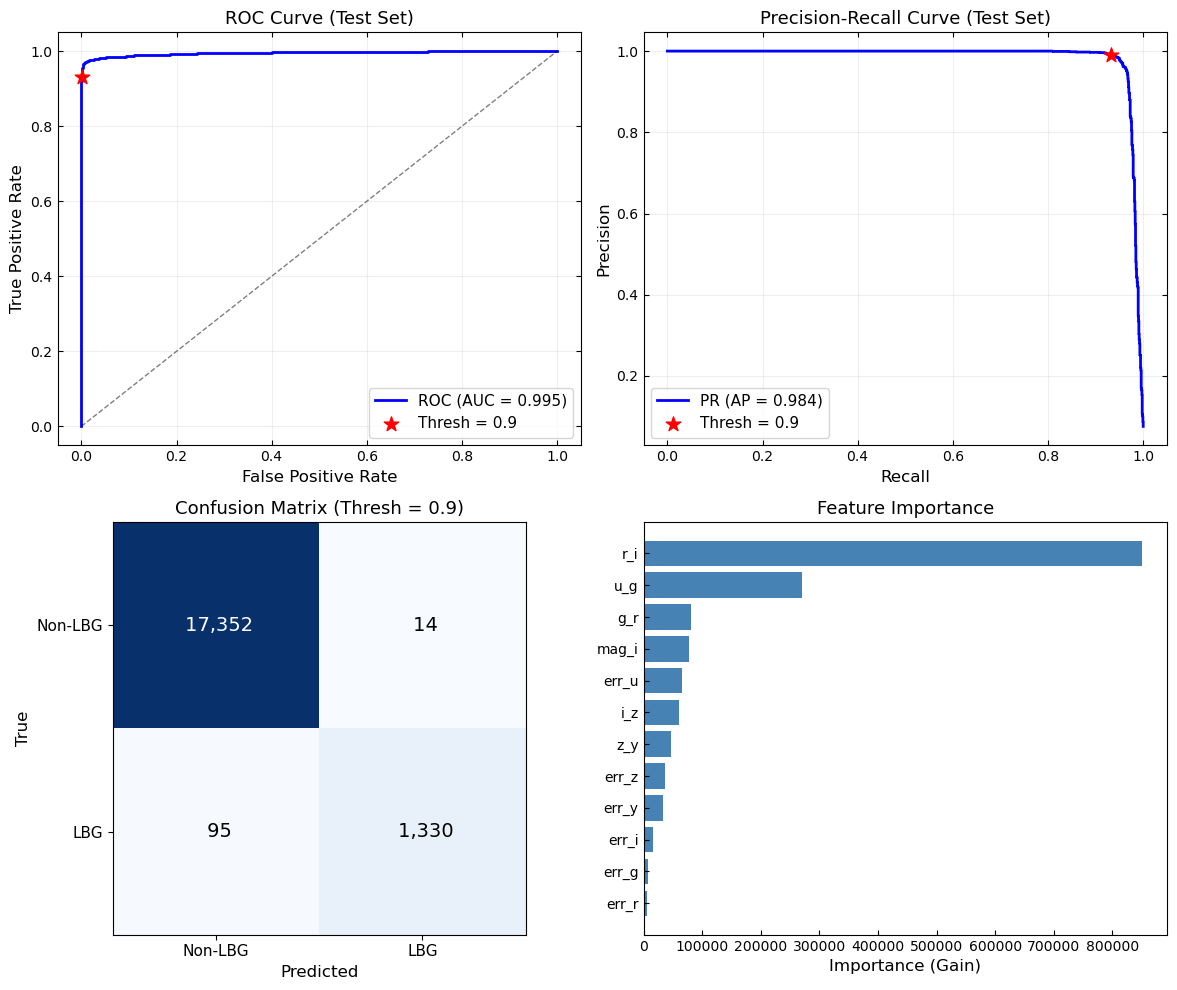

In [21]:
# =============================================================================
# 11. VISUALIZATION
# =============================================================================
print("\n" + "=" * 70)
print("STEP 10: CREATING FIGURES")
print("=" * 70)

# Define threshold
PROB_THRESH = 0.9

# Predictions at chosen threshold
y_test_class = (y_test_pred >= PROB_THRESH).astype(int)

# Recalculate metrics at this threshold
test_prec = precision_score(y_test, y_test_class, zero_division=0)
test_rec = recall_score(y_test, y_test_class, zero_division=0)
test_f1 = f1_score(y_test, y_test_class, zero_division=0)

print(f"Threshold: {PROB_THRESH}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:     {test_rec:.4f}")
print(f"  F1:        {test_f1:.4f}")
print(f"  N_selected: {y_test_class.sum():,}")

# Figure 1: Model Evaluation
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))

# (a) ROC Curve
ax = axes1[0, 0]
fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_pred)
ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {test_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

# Mark chosen threshold
idx_thresh = np.argmin(np. abs(thresholds_roc - PROB_THRESH))
ax.scatter(fpr[idx_thresh], tpr[idx_thresh], s=120, c='red', marker='*', 
           zorder=5, label=f'Thresh = {PROB_THRESH}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve (Test Set)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (b) Precision-Recall Curve
ax = axes1[0, 1]
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test, y_test_pred)
ap = average_precision_score(y_test, y_test_pred)
ax.plot(rec_curve, prec_curve, 'b-', lw=2, label=f'PR (AP = {ap:.3f})')

# Mark chosen threshold
idx_thresh_pr = np.argmin(np.abs(thresholds_pr - PROB_THRESH))
ax.scatter(rec_curve[idx_thresh_pr], prec_curve[idx_thresh_pr], s=120, c='red', 
           marker='*', zorder=5, label=f'Thresh = {PROB_THRESH}')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve (Test Set)', fontsize=13)
ax.legend(loc='lower left', fontsize=11)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (c) Confusion Matrix
ax = axes1[1, 0]
cm = confusion_matrix(y_test, y_test_class)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-LBG', 'LBG'], fontsize=11)
ax.set_yticklabels(['Non-LBG', 'LBG'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix (Thresh = {PROB_THRESH})', fontsize=13)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]: ,}', ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm. max()/2 else 'black')

# (d) Feature Importance
ax = axes1[1, 1]
importance_sorted = importance.sort_values('importance', ascending=True)
ax.barh(importance_sorted['feature'], importance_sorted['importance'], color='steelblue')
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Feature Importance', fontsize=13)
ax.tick_params(axis='both', labelsize=10, direction='in')

plt.tight_layout()
plt.savefig('../images/model_evaluation_planB.png', dpi=600, bbox_inches='tight')
plt.show()

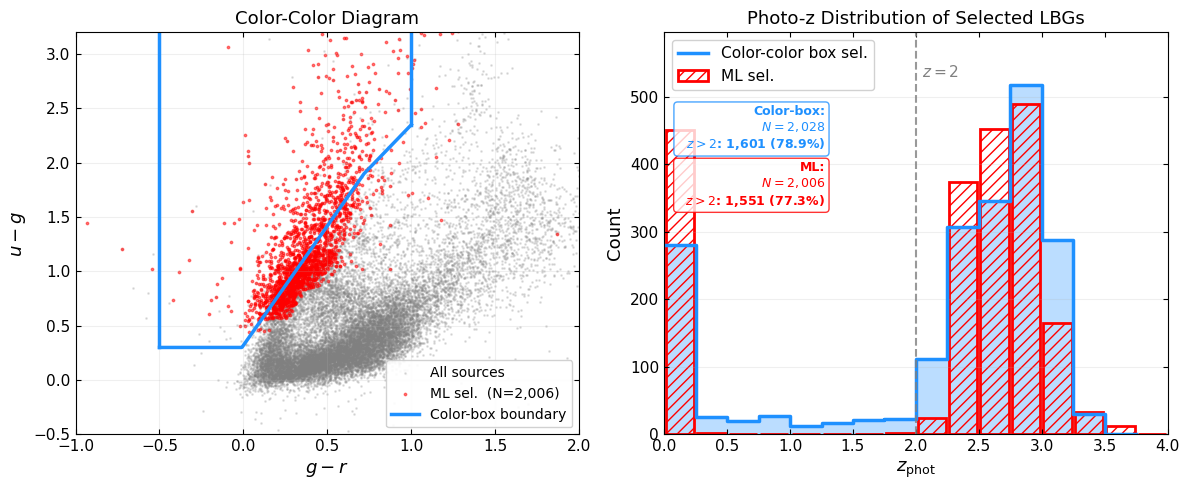

In [23]:
# -----------------------------------------------------------------------------
# Figure 2: ML vs Color-Box Comparison
# -----------------------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# (a) Color-color diagram
ax = axes2[0]
sample_idx = np.random.choice(len(g_r_all), min(20000, len(g_r_all)), replace=False)
ax.scatter(g_r_all[sample_idx], u_g_all[sample_idx], s=1, alpha=0.2, c='gray',
           rasterized=True, label='All sources')
ax.scatter(g_r_all[mask_ml_lbg], u_g_all[mask_ml_lbg], s=3, alpha=0.5, c='red',
           rasterized=True, label=f'ML sel.  (N={n_ml_lbg:,})')

# Color-box boundary
g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75)))
                        for gr in g_r_line])
ax.plot(g_r_line, lower_bound, 'dodgerblue', lw=2.5, label='Color-box boundary')
ax.plot([-0.5, -0.5], [lower_bound[0], 3.5], 'dodgerblue', lw=2.5)
ax.plot([1.0, 1.0], [lower_bound[-1], 3.5], 'dodgerblue', lw=2.5)

ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-0.5, 3.2)
ax.set_xlabel(r'$g - r$', fontsize=13)
ax.set_ylabel(r'$u - g$', fontsize=13)
ax.set_title('Color-Color Diagram', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (b) Photo-z histogram comparison
ax = axes2[1]
bins = np.arange(0, 4.25, 0.25)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

counts_box, _ = np.histogram(zphot_box, bins=bins)
ax.step(bins[:-1], counts_box, where='post', color='dodgerblue', lw=2.5,
        label='Color-color box sel.')
ax.fill_between(bins[:-1], counts_box, step='post', alpha=0.3, color='dodgerblue')

counts_ml, _ = np. histogram(zphot_ml_lbg, bins=bins)
ax.bar(bin_centers, counts_ml, width=bin_width * 0.9, fill=False,
       edgecolor='red', linewidth=2, hatch='///', label='ML sel.')

y_max = max(counts_box. max(), counts_ml.max()) * 1.15
ax.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax.text(2.05, y_max * 0.92, r'$z=2$', fontsize=11, color='gray', va='top')

ax.set_xlim(0, 4.0)
ax.set_ylim(0, y_max)
ax.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Photo-z Distribution of Selected LBGs', fontsize=13)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2, axis='y')

# Statistics
n_box_z2 = (zphot_box > 2).sum()
frac_box_z2 = n_box_z2 / len(zphot_box) * 100 if len(zphot_box) > 0 else 0
stats_box = f'Color-box:\n  $N = {len(zphot_box):,}$\n  $z > 2$: {n_box_z2:,} ({frac_box_z2:.1f}%)'

n_ml_z2 = (zphot_ml_lbg > 2).sum()
frac_ml_z2 = n_ml_z2 / len(zphot_ml_lbg) * 100 if len(zphot_ml_lbg) > 0 else 0
stats_ml = f'ML:\n  $N = {len(zphot_ml_lbg):,}$\n  $z > 2$: {n_ml_z2:,} ({frac_ml_z2:.1f}%)'

ax.text(0.32, 0.82, stats_box, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='dodgerblue', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='dodgerblue'))
ax.text(0.32, 0.68, stats_ml, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.savefig('../images/ml_vs_colorbox_planB.png', dpi=600, bbox_inches='tight')
plt.show()

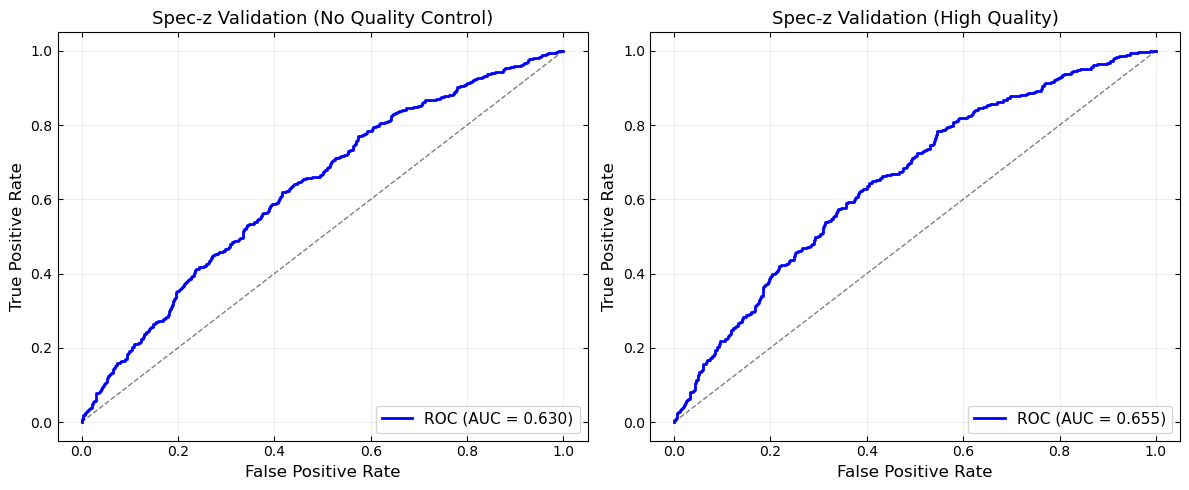

In [46]:
# -----------------------------------------------------------------------------
# Figure 3: Spectroscopic Validation
# -----------------------------------------------------------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

# (a) Version 1: No quality control
ax = axes3[0]
if valid_v1.sum() > 0:
    fpr_v1, tpr_v1, _ = roc_curve(is_lbg_spec_v1[valid_v1], y_pred_spec[valid_v1])
    ax.plot(fpr_v1, tpr_v1, 'b-', lw=2, label=f'ROC (AUC = {auc_v1:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Spec-z Validation (No Quality Control)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# (b) Version 2: With quality control
ax = axes3[1]
if valid_v2.sum() > 0:
    fpr_v2, tpr_v2, _ = roc_curve(y_true_v2, y_prob_v2)
    ax.plot(fpr_v2, tpr_v2, 'b-', lw=2, label=f'ROC (AUC = {auc_v2:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Spec-z Validation (High Quality)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../images/spec_validation_planB2.png', dpi=600, bbox_inches='tight')
plt.show()

## Optimized Plan B-2: Adaptive Threshold with Probability Calibration

### Strategy Overview

This approach addresses the **threshold drift problem** observed in the original Plan B-2, where a threshold of 0.9 worked well on the test set but required an extreme threshold of 0.99985 on the full dataset to achieve comparable purity to the color-box method.

### Key Optimizations

| Component | Description |
|:----------|:------------|
| **Sample Weighting** | High-quality sources (σ_z/z < 0.05) receive weight=1.0; lower-quality sources receive weight=0.5 |
| **Full Dataset Training** | Train on all 132,955 sources (with weights) instead of only the high-quality subset |
| **Probability Calibration** | Apply Isotonic Regression to correct systematic biases in predicted probabilities |
| **Adaptive Threshold** | Automatically find the optimal threshold to achieve target purity |

### Workflow

```
Full Dataset (132,955 sources)
         │
         ├── Assign sample weights based on photo-z quality
         │
         ├── 70/30 stratified train/test split
         │
         ├── Train LightGBM with weighted samples
         │
         ├── Predict probabilities on full dataset
         │
         ├── Calibrate probabilities using Isotonic Regression
         │
         └── Apply adaptive threshold for target purity
```

In [29]:
# =============================================================================
# OPTIMIZED PLAN B-2: Data Preparation
# =============================================================================
# This cell prepares the full dataset with sample weights based on photo-z quality

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn. isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, average_precision_score, confusion_matrix
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("OPTIMIZED PLAN B-2: Adaptive Threshold + Probability Calibration")
print("=" * 70)

# -----------------------------------------------------------------------------
# Define features
# -----------------------------------------------------------------------------
FEATURES = ['u_g', 'g_r', 'r_i', 'i_z', 'z_y', 'mag_i',
            'err_u', 'err_g', 'err_r', 'err_i', 'err_z', 'err_y']

# -----------------------------------------------------------------------------
# Extract data from df_all (prepared in previous cells)
# -----------------------------------------------------------------------------
X_all = df_all[FEATURES].values
y_all = df_all['is_lbg'].values
z_rel_err_all = df_all['z_rel_err'].values
zphot_all = df_all['zphot'].values

# -----------------------------------------------------------------------------
# Compute sample weights based on photo-z quality
# High-quality (σ_z/z < 0.05): weight = 1.0
# Low-quality (σ_z/z >= 0.05): weight = 0.5
# -----------------------------------------------------------------------------
QUALITY_THRESHOLD = 0.05
sample_weights = np.where(z_rel_err_all < QUALITY_THRESHOLD, 1.0, 0.5)

n_hq = (z_rel_err_all < QUALITY_THRESHOLD).sum()
n_lq = (z_rel_err_all >= QUALITY_THRESHOLD).sum()

print(f"\n[1] Data Summary:")
print(f"    Total sources: {len(X_all):,}")
print(f"    High-quality (σ_z/z < {QUALITY_THRESHOLD}): {n_hq:,} ({n_hq/len(X_all)*100:.1f}%)")
print(f"    Low-quality:  {n_lq:,} ({n_lq/len(X_all)*100:.1f}%)")
print(f"    LBG (ZPHOT > 2): {y_all.sum():,} ({y_all.mean()*100:.2f}%)")

OPTIMIZED PLAN B-2: Adaptive Threshold + Probability Calibration

[1] Data Summary:
    Total sources: 132,955
    High-quality (σ_z/z < 0.05): 62,634 (47.1%)
    Low-quality:  70,321 (52.9%)
    LBG (ZPHOT > 2): 7,408 (5.57%)


In [30]:
# =============================================================================
# Train/Test Split (70/30 stratified)
# =============================================================================

X_train, X_test, y_train, y_test, w_train, w_test, idx_train, idx_test = train_test_split(
    X_all, y_all, sample_weights, np.arange(len(X_all)),
    test_size=0.3, stratify=y_all, random_state=42
)

print(f"\n[2] Train/Test Split:")
print(f"    Training set: {len(X_train):,} ({len(X_train)/len(X_all)*100:.0f}%)")
print(f"      - LBG: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"    Test set: {len(X_test):,} ({len(X_test)/len(X_all)*100:.0f}%)")
print(f"      - LBG: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


[2] Train/Test Split:
    Training set: 93,068 (70%)
      - LBG: 5,186 (5.57%)
    Test set: 39,887 (30%)
      - LBG: 2,222 (5.57%)


In [31]:
# =============================================================================
# LightGBM Training with Sample Weights
# =============================================================================

# Model parameters (optimized for full dataset)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': 6,
    'learning_rate':  0.03,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda':  0.1,
    'is_unbalance': True,
    'random_state': 42,
    'verbose': -1,
}

print(f"\n[3] Training LightGBM Model...")

# Create datasets with weights
train_data = lgb.Dataset(X_train, label=y_train, weight=w_train)
val_data = lgb.Dataset(X_test, label=y_test, weight=w_test, reference=train_data)

# Train with early stopping
model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

print(f"    Training complete:  {model.num_trees()} trees")

# Evaluate on test set (before calibration)
y_test_prob = model.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_prob)
print(f"    Test AUC (before calibration): {test_auc:.4f}")


[3] Training LightGBM Model...
    Training complete:  500 trees
    Test AUC (before calibration): 0.9895


In [32]:
# =============================================================================
# Probability Calibration using Isotonic Regression
# =============================================================================

print(f"\n[4] Probability Calibration...")

# Predict on full dataset
y_prob_all = model.predict(X_all)

# Fit Isotonic Regression on test set
ir = IsotonicRegression(out_of_bounds='clip')
ir.fit(y_prob_all[idx_test], y_all[idx_test])

# Transform all probabilities
y_prob_calibrated = ir.transform(y_prob_all)

# Compare calibration effect
print(f"    Original prob range: [{y_prob_all. min():.4f}, {y_prob_all.max():.4f}]")
print(f"    Calibrated prob range: [{y_prob_calibrated.min():.4f}, {y_prob_calibrated.max():.4f}]")

# AUC should remain similar
auc_original = roc_auc_score(y_all, y_prob_all)
auc_calibrated = roc_auc_score(y_all, y_prob_calibrated)
print(f"    AUC (original): {auc_original:.4f}")
print(f"    AUC (calibrated): {auc_calibrated:.4f}")


[4] Probability Calibration...
    Original prob range: [0.0000, 0.9999]
    Calibrated prob range: [0.0000, 1.0000]
    AUC (original): 0.9951
    AUC (calibrated): 0.9953


In [39]:
# =============================================================================
# Adaptive Threshold Selection
# =============================================================================

def find_optimal_threshold(y_true, y_prob, target_purity=0.80):
    """Find the lowest threshold that achieves target purity."""
    thresholds = np.linspace(0.3, 0.999, 200)
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        if y_pred.sum() > 0:
            purity = (y_true[y_pred == 1] == 1).mean()
            if purity >= target_purity:
                return thresh, purity, y_pred. sum()
    return 0.999, 0.0, 0

print(f"\n[5] Adaptive Threshold Selection:")

# Find thresholds for different target purities
targets = [0.70, 0.78, 0.85, 0.90]
print(f"\n    {'Target Purity': >15} {'Threshold':>12} {'Actual Purity':>15} {'N Selected':>12}")
print("    " + "-" * 58)

for target in targets: 
    thresh, actual, n_sel = find_optimal_threshold(y_all, y_prob_calibrated, target)
    print(f"    {target*100:>14.0f}% {thresh: >12.4f} {actual*100:>14.1f}% {n_sel: >12,}")

# Use threshold for ~78% purity (comparable to color-box)
TARGET_PURITY = 0.9
optimal_thresh_raw, actual_purity, n_selected = find_optimal_threshold(
    y_all, y_prob_calibrated, TARGET_PURITY
)

optimal_thresh = optimal_thresh_raw
print(f"\n    Selected threshold: {optimal_thresh:.4f} (target: {TARGET_PURITY*100:.0f}%)")


[5] Adaptive Threshold Selection:

      Target Purity    Threshold   Actual Purity   N Selected
    ----------------------------------------------------------
                70%       0.3000           85.4%        7,961
                78%       0.3000           85.4%        7,961
                85%       0.3000           85.4%        7,961
                90%       0.5353           92.0%        6,776

    Selected threshold: 0.5353 (target: 90%)


In [45]:
# =============================================================================
# Test Set Evaluation (Primary Validation)
# =============================================================================
# This is the proper evaluation on held-out data

print(f"\n[6] Test Set Evaluation (Primary Validation):")
print("=" * 60)

# Get test set predictions (calibrated)
y_prob_test_calibrated = y_prob_calibrated[idx_test]
zphot_test = zphot_all[idx_test]
u_g_test = u_g_all[idx_test]
g_r_test = g_r_all[idx_test]

# -----------------------------------------------------------------------------
# Find optimal threshold on test set
# -----------------------------------------------------------------------------
def find_optimal_threshold(y_true, y_prob, target_purity=0.80):
    """Find the lowest threshold that achieves target purity."""
    thresholds = np.linspace(0.3, 0.999, 200)
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        if y_pred.sum() > 0:
            purity = (y_true[y_pred == 1] == 1).mean()
            if purity >= target_purity:
                return thresh, purity, y_pred. sum()
    return 0.999, 0.0, 0

# Find thresholds for different target purities on TEST SET
TARGET_PURITY = 0.9
optimal_thresh, actual_purity, n_selected = find_optimal_threshold(
    y_test, y_prob_test_calibrated, TARGET_PURITY
)

print(f"\n    Optimal threshold (on test set): {optimal_thresh:.4f}")
print(f"    Target purity: {TARGET_PURITY*100:.0f}%")

# -----------------------------------------------------------------------------
# ML selection on test set
# -----------------------------------------------------------------------------
y_pred_test = (y_prob_test_calibrated >= optimal_thresh).astype(int)
mask_ml_test = y_pred_test == 1

n_ml_test = mask_ml_test.sum()
zphot_ml_test = zphot_test[mask_ml_test]
n_ml_test_z2 = (zphot_ml_test > 2).sum()
purity_ml_test = n_ml_test_z2 / n_ml_test * 100 if n_ml_test > 0 else 0

# -----------------------------------------------------------------------------
# Color-box selection on test set
# -----------------------------------------------------------------------------
cond_ug_test = u_g_test > 0.3
cond_gr_test = (g_r_test > -0.5) & (g_r_test < 1.0)
cond_diag_test = (u_g_test > (2.2*g_r_test + 0.32)) | \
                 ((u_g_test > (1.6*g_r_test + 0.75)) & (u_g_test > 0.9))
mask_box_test = cond_ug_test & cond_gr_test & cond_diag_test

n_box_test = mask_box_test. sum()
zphot_box_test = zphot_test[mask_box_test]
n_box_test_z2 = (zphot_box_test > 2).sum()
purity_box_test = n_box_test_z2 / n_box_test * 100 if n_box_test > 0 else 0

# -----------------------------------------------------------------------------
# Overlap analysis on test set
# -----------------------------------------------------------------------------
both_test = mask_ml_test & mask_box_test
ml_only_test = mask_ml_test & ~mask_box_test
box_only_test = ~mask_ml_test & mask_box_test

# -----------------------------------------------------------------------------
# Print results
# -----------------------------------------------------------------------------
print(f"\n    TEST SET RESULTS (N = {len(y_test):,}):")
print(f"    ┌─────────────────┬──────────────┬─────────────┬──────────┐")
print(f"    │ Method          │ N Selected   │ z_phot > 2  │ Purity   │")
print(f"    ├─────────────────┼──────────────┼─────────────┼──────────┤")
print(f"    │ Color-box       │ {n_box_test:>10,} │ {n_box_test_z2:>9,}   │ {purity_box_test:>6.1f}%  │")
print(f"    │ ML (calibrated) │ {n_ml_test: >10,} │ {n_ml_test_z2:>9,}   │ {purity_ml_test:>6.1f}%  │")
print(f"    └─────────────────┴──────────────┴─────────────┴──────────┘")

print(f"\n    Overlap Analysis (Test Set):")
print(f"      Both methods: {both_test. sum():,}")
print(f"      ML only: {ml_only_test.sum():,}")
print(f"      Color-box only: {box_only_test.sum():,}")

print(f"\n    Improvement over Color-box (Test Set):")
print(f"      Selection increase: {(n_ml_test/n_box_test - 1)*100:+.1f}%" if n_box_test > 0 else "      N/A")
print(f"      Purity change: {purity_ml_test - purity_box_test:+.1f}%")


[6] Test Set Evaluation (Primary Validation):

    Optimal threshold (on test set): 0.5353
    Target purity: 90%

    TEST SET RESULTS (N = 39,887):
    ┌─────────────────┬──────────────┬─────────────┬──────────┐
    │ Method          │ N Selected   │ z_phot > 2  │ Purity   │
    ├─────────────────┼──────────────┼─────────────┼──────────┤
    │ Color-box       │        636 │       505   │   79.4%  │
    │ ML (calibrated) │      1,957 │     1,778   │   90.9%  │
    └─────────────────┴──────────────┴─────────────┴──────────┘

    Overlap Analysis (Test Set):
      Both methods: 491
      ML only: 1,466
      Color-box only: 145

    Improvement over Color-box (Test Set):
      Selection increase: +207.7%
      Purity change: +11.5%


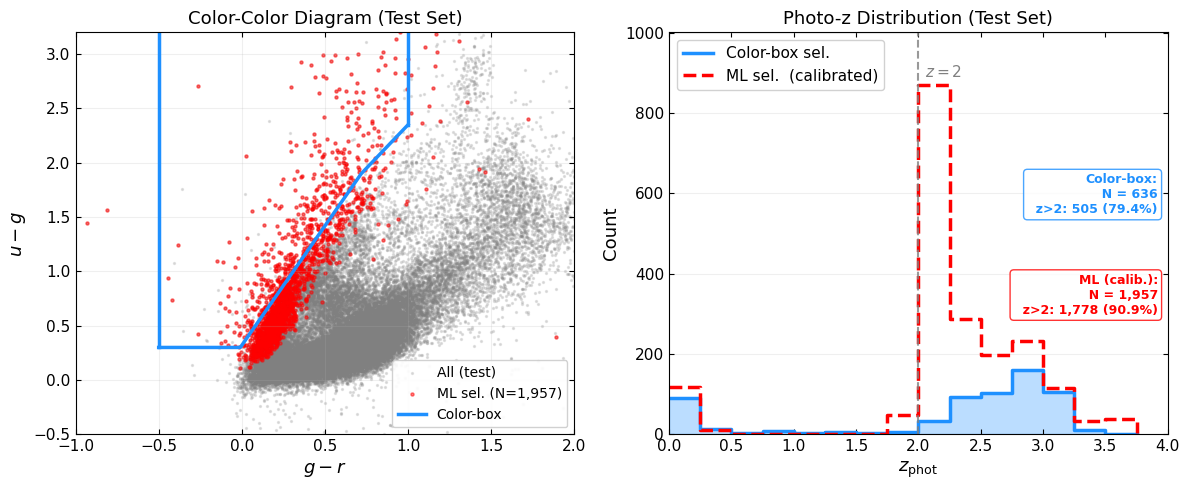

✓ Figure saved:  ../images/ml_vs_colorbox_testset.png


In [48]:
# =============================================================================
# Test Set Visualization
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# (a) Color-color Diagram (Test Set)
# -----------------------------------------------------------------------------
ax = axes[0]

# Background:  all test sources
ax.scatter(g_r_test, u_g_test, s=2, alpha=0.2, c='gray',
           rasterized=True, label='All (test)')

# ML selected (test)
ax.scatter(g_r_test[mask_ml_test], u_g_test[mask_ml_test], s=5, alpha=0.5, c='red',
           rasterized=True, label=f'ML sel. (N={n_ml_test:,})')

# Color-box boundary
g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75)))
                        for gr in g_r_line])
ax.plot(g_r_line, lower_bound, 'dodgerblue', lw=2.5, label='Color-box')
ax.plot([-0.5, -0.5], [lower_bound[0], 3.5], 'dodgerblue', lw=2.5)
ax.plot([1.0, 1.0], [lower_bound[-1], 3.5], 'dodgerblue', lw=2.5)

ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-0.5, 3.2)
ax.set_xlabel(r'$g - r$', fontsize=13)
ax.set_ylabel(r'$u - g$', fontsize=13)
ax.set_title('Color-Color Diagram (Test Set)', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# -----------------------------------------------------------------------------
# (b) Photo-z Distribution (Test Set)
# -----------------------------------------------------------------------------
ax = axes[1]

bins = np.arange(0, 4.25, 0.25)

# Color-box histogram
counts_box_test, _ = np.histogram(zphot_box_test, bins=bins)
ax.step(bins[:-1], counts_box_test, where='post', color='dodgerblue', lw=2.5,
        label='Color-box sel.')
ax.fill_between(bins[:-1], counts_box_test, step='post', alpha=0.3, color='dodgerblue')

# ML histogram
counts_ml_test, _ = np.histogram(zphot_ml_test, bins=bins)
ax.step(bins[:-1], counts_ml_test, where='post', color='red', lw=2.5,
        label='ML sel.  (calibrated)', linestyle='--')

# Reference line
y_max = max(counts_box_test. max(), counts_ml_test.max()) * 1.15 if counts_box_test.max() > 0 else 100
ax.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax.text(2.05, y_max * 0.92, r'$z=2$', fontsize=11, color='gray', va='top')

ax.set_xlim(0, 4.0)
ax.set_ylim(0, y_max)
ax.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Photo-z Distribution (Test Set)', fontsize=13)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2, axis='y')

# Statistics annotations
stats_box = f'Color-box:\n  N = {n_box_test:,}\n  z>2: {n_box_test_z2:,} ({purity_box_test:.1f}%)'
stats_ml = f'ML (calib.):\n  N = {n_ml_test:,}\n  z>2: {n_ml_test_z2:,} ({purity_ml_test:.1f}%)'

ax.text(0.98, 0.65, stats_box, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='dodgerblue', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='dodgerblue'))
ax.text(0.98, 0.40, stats_ml, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.savefig('../images/ml_vs_colorbox_testset.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved:  ../images/ml_vs_colorbox_testset.png")

In [50]:
# =============================================================================
# Full Dataset Application (Using threshold from test set)
# =============================================================================
# Apply the threshold determined on test set to the full dataset

print(f"\n[7] Full Dataset Application:")
print("=" * 60)
print(f"    Using threshold = {optimal_thresh:.4f} (determined on test set)")

# -----------------------------------------------------------------------------
# ML selection on full dataset
# -----------------------------------------------------------------------------
y_pred_all = (y_prob_calibrated >= optimal_thresh).astype(int)
mask_ml_all = y_pred_all == 1

n_ml_all = mask_ml_all.sum()
zphot_ml_all = zphot_all[mask_ml_all]
n_ml_all_z2 = (zphot_ml_all > 2).sum()
purity_ml_all = n_ml_all_z2 / n_ml_all * 100 if n_ml_all > 0 else 0

# -----------------------------------------------------------------------------
# Color-box selection on full dataset
# -----------------------------------------------------------------------------
cond_ug_all = u_g_all > 0.3
cond_gr_all = (g_r_all > -0.5) & (g_r_all < 1.0)
cond_diag_all = (u_g_all > (2.2*g_r_all + 0.32)) | \
                ((u_g_all > (1.6*g_r_all + 0.75)) & (u_g_all > 0.9))
mask_box_all = cond_ug_all & cond_gr_all & cond_diag_all

n_box_all = mask_box_all.sum()
zphot_box_all = zphot_all[mask_box_all]
n_box_all_z2 = (zphot_box_all > 2).sum()
purity_box_all = n_box_all_z2 / n_box_all * 100 if n_box_all > 0 else 0

# -----------------------------------------------------------------------------
# Overlap analysis
# -----------------------------------------------------------------------------
both_all = mask_ml_all & mask_box_all
ml_only_all = mask_ml_all & ~mask_box_all
box_only_all = ~mask_ml_all & mask_box_all

# -----------------------------------------------------------------------------
# Print results
# -----------------------------------------------------------------------------
print(f"\n    FULL DATASET RESULTS (N = {len(y_all):,}):")
print(f"    ┌─────────────────┬──────────────┬─────────────┬──────────┐")
print(f"    │ Method          │ N Selected   │ z_phot > 2  │ Purity   │")
print(f"    ├─────────────────┼──────────────┼─────────────┼──────────┤")
print(f"    │ Color-box       │ {n_box_all:>10,} │ {n_box_all_z2:>9,}   │ {purity_box_all:>6.1f}%  │")
print(f"    │ ML (calibrated) │ {n_ml_all:>10,} │ {n_ml_all_z2:>9,}   │ {purity_ml_all:>6.1f}%  │")
print(f"    └─────────────────┴──────────────┴─────────────┴──────────┘")

print(f"\n    Overlap Analysis (Full Dataset):")
print(f"      Both methods: {both_all. sum():,}")
print(f"      ML only: {ml_only_all.sum():,}")
print(f"      Color-box only: {box_only_all.sum():,}")

# -----------------------------------------------------------------------------
# Consistency check:  Test vs Full
# -----------------------------------------------------------------------------
print(f"\n    Consistency Check (Test → Full):")
print(f"      Test set purity: {purity_ml_test:.1f}%")
print(f"      Full set purity: {purity_ml_all:.1f}%")
print(f"      Difference: {abs(purity_ml_all - purity_ml_test):.1f}%")

if abs(purity_ml_all - purity_ml_test) < 3.0:
    print(f"    ✓ Results are consistent (Δ < 3%)")
else:
    print(f"    ⚠ Results differ significantly (Δ >= 3%)")


[7] Full Dataset Application:
    Using threshold = 0.5353 (determined on test set)

    FULL DATASET RESULTS (N = 132,955):
    ┌─────────────────┬──────────────┬─────────────┬──────────┐
    │ Method          │ N Selected   │ z_phot > 2  │ Purity   │
    ├─────────────────┼──────────────┼─────────────┼──────────┤
    │ Color-box       │      2,028 │     1,601   │   78.9%  │
    │ ML (calibrated) │      6,776 │     6,234   │   92.0%  │
    └─────────────────┴──────────────┴─────────────┴──────────┘

    Overlap Analysis (Full Dataset):
      Both methods: 1,593
      ML only: 5,183
      Color-box only: 435

    Consistency Check (Test → Full):
      Test set purity: 90.9%
      Full set purity: 92.0%
      Difference: 1.1%
    ✓ Results are consistent (Δ < 3%)


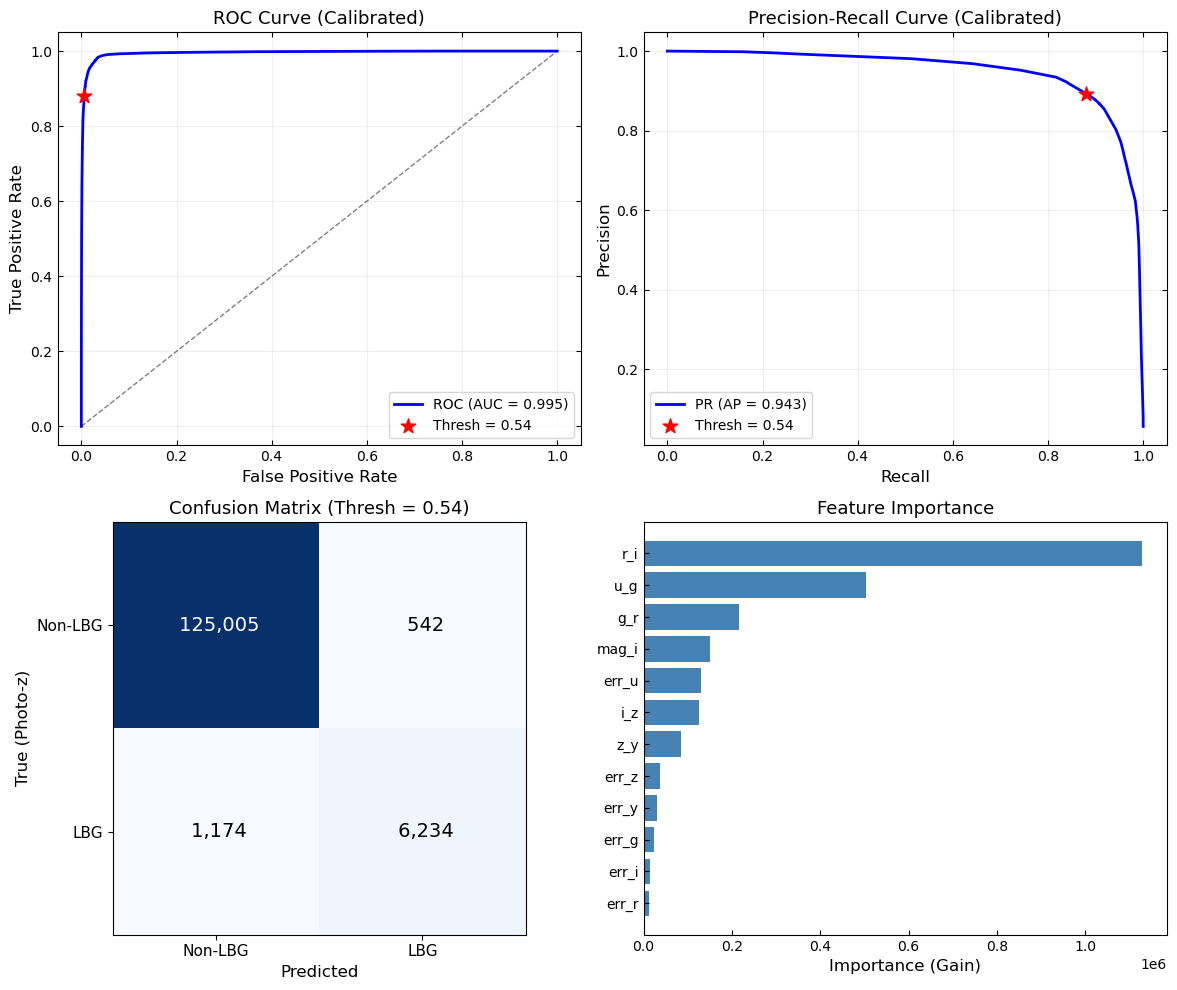

✓ Figure saved:  ../images/model_evaluation_planB2_optimized.png


In [54]:
# =============================================================================
# Model Evaluation Visualization
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -----------------------------------------------------------------------------
# (a) ROC Curve
# -----------------------------------------------------------------------------
ax = axes[0, 0]
fpr, tpr, thresholds_roc = roc_curve(y_all, y_prob_calibrated)
ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc_calibrated:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

# Mark optimal threshold
idx_opt = np.argmin(np. abs(thresholds_roc - optimal_thresh))
ax.scatter(fpr[idx_opt], tpr[idx_opt], s=120, c='red', marker='*', 
           zorder=5, label=f'Thresh = {optimal_thresh:.2f}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve (Calibrated)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# -----------------------------------------------------------------------------
# (b) Precision-Recall Curve
# -----------------------------------------------------------------------------
ax = axes[0, 1]
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_all, y_prob_calibrated)
ap = average_precision_score(y_all, y_prob_calibrated)
ax.plot(rec_curve, prec_curve, 'b-', lw=2, label=f'PR (AP = {ap:.3f})')

# Mark optimal threshold
idx_opt_pr = np.argmin(np.abs(thresholds_pr - optimal_thresh))
ax.scatter(rec_curve[idx_opt_pr], prec_curve[idx_opt_pr], s=120, c='red', 
           marker='*', zorder=5, label=f'Thresh = {optimal_thresh:.2f}')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve (Calibrated)', fontsize=13)
ax.legend(loc='lower left', fontsize=10)
ax.tick_params(axis='both', labelsize=10, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# -----------------------------------------------------------------------------
# (c) Confusion Matrix
# -----------------------------------------------------------------------------
ax = axes[1, 0]
cm = confusion_matrix(y_all, y_pred_all)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-LBG', 'LBG'], fontsize=11)
ax.set_yticklabels(['Non-LBG', 'LBG'], fontsize=11)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True (Photo-z)', fontsize=12)
ax.set_title(f'Confusion Matrix (Thresh = {optimal_thresh:.2f})', fontsize=13)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]: ,}', ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm. max()/2 else 'black')

# -----------------------------------------------------------------------------
# (d) Feature Importance
# -----------------------------------------------------------------------------
ax = axes[1, 1]
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Feature Importance', fontsize=13)
ax.tick_params(axis='both', labelsize=10, direction='in')

plt.tight_layout()
plt.savefig('../images/model_evaluation_planB2_optimized.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved:  ../images/model_evaluation_planB2_optimized.png")

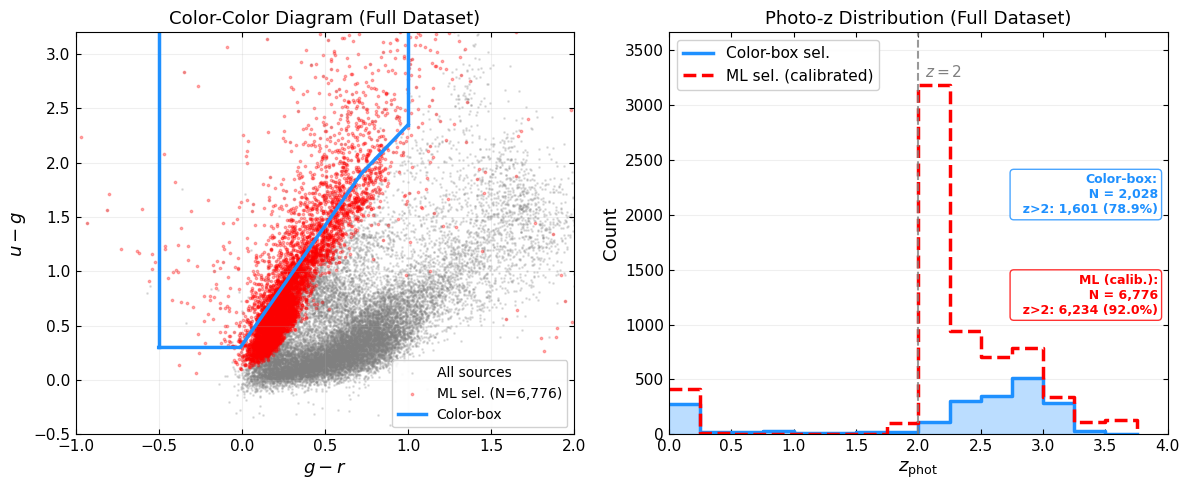

✓ Figure saved: ../images/ml_vs_colorbox_fullset.png


In [52]:
# =============================================================================
# Full Dataset Visualization
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------------------------------------------------
# (a) Color-color Diagram (Full Dataset)
# -----------------------------------------------------------------------------
ax = axes[0]

sample_idx = np.random.choice(len(g_r_all), min(20000, len(g_r_all)), replace=False)
ax.scatter(g_r_all[sample_idx], u_g_all[sample_idx], s=1, alpha=0.2, c='gray',
           rasterized=True, label='All sources')

ax.scatter(g_r_all[mask_ml_all], u_g_all[mask_ml_all], s=3, alpha=0.3, c='red',
           rasterized=True, label=f'ML sel. (N={n_ml_all:,})')

g_r_line = np.linspace(-0.5, 1.0, 400)
lower_bound = np.array([max(0.3, min(2.2*gr + 0.32, max(0.9, 1.6*gr + 0.75)))
                        for gr in g_r_line])
ax.plot(g_r_line, lower_bound, 'dodgerblue', lw=2.5, label='Color-box')
ax.plot([-0.5, -0.5], [lower_bound[0], 3.5], 'dodgerblue', lw=2.5)
ax.plot([1.0, 1.0], [lower_bound[-1], 3.5], 'dodgerblue', lw=2.5)

ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-0.5, 3.2)
ax.set_xlabel(r'$g - r$', fontsize=13)
ax.set_ylabel(r'$u - g$', fontsize=13)
ax.set_title('Color-Color Diagram (Full Dataset)', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2)

# -----------------------------------------------------------------------------
# (b) Photo-z Distribution (Full Dataset)
# -----------------------------------------------------------------------------
ax = axes[1]

bins = np.arange(0, 4.25, 0.25)

counts_box_all, _ = np.histogram(zphot_box_all, bins=bins)
ax.step(bins[:-1], counts_box_all, where='post', color='dodgerblue', lw=2.5,
        label='Color-box sel.')
ax.fill_between(bins[:-1], counts_box_all, step='post', alpha=0.3, color='dodgerblue')

counts_ml_all, _ = np. histogram(zphot_ml_all, bins=bins)
ax.step(bins[:-1], counts_ml_all, where='post', color='red', lw=2.5,
        label='ML sel. (calibrated)', linestyle='--')

y_max = max(counts_box_all.max(), counts_ml_all.max()) * 1.15
ax.axvline(x=2.0, color='gray', linestyle='--', lw=1.5, alpha=0.8)
ax.text(2.05, y_max * 0.92, r'$z=2$', fontsize=11, color='gray', va='top')

ax.set_xlim(0, 4.0)
ax.set_ylim(0, y_max)
ax.set_xlabel(r'$z_{\rm phot}$', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Photo-z Distribution (Full Dataset)', fontsize=13)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.tick_params(axis='both', labelsize=11, direction='in', top=True, right=True)
ax.grid(True, alpha=0.2, axis='y')

stats_box = f'Color-box:\n  N = {n_box_all:,}\n  z>2: {n_box_all_z2:,} ({purity_box_all:.1f}%)'
stats_ml = f'ML (calib.):\n  N = {n_ml_all:,}\n  z>2: {n_ml_all_z2:,} ({purity_ml_all:.1f}%)'

ax.text(0.98, 0.65, stats_box, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='dodgerblue', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='dodgerblue'))
ax.text(0.98, 0.40, stats_ml, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.savefig('../images/ml_vs_colorbox_fullset.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: ../images/ml_vs_colorbox_fullset.png")